In [53]:
import sys
from pathlib import Path
import math

import pandas as pd
from scipy.stats import beta, gamma, norm, t, gengamma
from scipy import special
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

from utils.cred_intervals import credible_intervals
from utils.triple_plot import normality_report

# Entrega avance 1 proyecto Finca Raiz Bayesiana
* Fecha: 23/09/2026
* Asignatura: Estadística Bayesiana - 4to Semestre
* Autores: **Julian Rodriguez Ramirez, Juan Pablo Carrillo Hortua, Samuel Acosta Morales**
* Pregrado Ciencia de Datos Universidad Externado, Bogota - Colombia
* Periodo 2026 - 2

In [54]:
# 1. Datos (DataFrame con columna de éxitos/fracasos: 1 o 0)
df = pd.read_csv("../data/datos_inmobiliarios_ready.csv")
df.head()

,price_amount,admin_fee,area_built_m2,bedrooms,bathrooms,parking_spaces,stratum,floor,age_bracket_code,latitude,...,locality_frec,neighborhood_grouped_frec,publisher_type_desarrollador,publisher_type_inmobiliaria,property_type_apartaestudio,property_type_casa,property_type_casa_campestre,property_type_finca,property_type_habitacion,meses_ofertado
0,8.800000e+08,736000.00,160.000,3.0,3.0,2,4.0,2,4.0,4.711642,...,0.275462,0.690441,0,0,0,1,0,0,0,43
1,6.500000e+08,271123.04,153.400,4.0,2.0,1,3.0,2,5.0,4.655459,...,0.060219,0.690441,0,0,0,1,0,0,0,43
2,6.250000e+08,643500.00,120.000,4.0,3.0,2,5.0,1,4.0,4.764007,...,0.310195,0.690441,0,0,0,1,0,0,0,42
3,4.700000e+08,560000.00,56.000,1.0,2.0,1,4.0,2,2.0,4.721554,...,0.310195,0.690441,0,0,0,0,0,0,0,41
4,1.170000e+09,869954.98,79.473,2.0,2.0,2,6.0,14,1.0,4.685839,...,0.310195,0.025536,0,1,0,0,0,0,0,41


# Diccionario de variables

Variables de `datos_inmobiliarios_ready.csv` (20.442 inmuebles en venta, 31 columnas), resultado de la limpieza (`data_cleaning.ipynb`) y la preparación (`data_preparation.ipynb`) de los anuncios de FincaRaíz. Las variables categóricas nominales se codificaron como variables dicotómicas (*dummies*) con una categoría de referencia, o por su frecuencia relativa.

El conjunto de datos fue scrapeado del portal FincaRaiz.com en agosto del 2026 y solo considero viviendas de Bogotá y alrededores.

| Variable | Unidad | Descripción | Tipo de variable | Escala |
|---|---|---|---|---|
| `price_amount` | COP | Precio de oferta publicado en el anuncio. | Cuantitativa continua | De razón |
| `admin_fee` | COP / mes | Cuota mensual de administración del inmueble; los valores faltantes se imputaron en la limpieza. | Cuantitativa continua | De razón |
| `area_built_m2` | m² | Área construida del inmueble. | Cuantitativa continua | De razón |
| `bedrooms` | conteo | Número de habitaciones. | Cuantitativa discreta | De razón |
| `bathrooms` | conteo | Número de baños. | Cuantitativa discreta | De razón |
| `parking_spaces` | conteo | Número de parqueaderos incluidos; los valores negativos se corrigieron y los faltantes se imputaron. | Cuantitativa discreta | De razón |
| `stratum` | 1–6 | Estrato socioeconómico asignado a la dirección del inmueble. | Cualitativa ordinal (codificada numéricamente) | Ordinal |
| `floor` | número de piso | Piso en el que se ubica el inmueble; los códigos mayores a 100 (p. ej. 301) se dividieron entre 100 y los faltantes se imputaron. | Cuantitativa discreta | De intervalo |
| `age_bracket_code` | 0–5 | Rango de antigüedad: 0 a estrenar, 1 menos de 1 año, 2 = 1–8, 3 = 9–15, 4 = 16–30, 5 más de 30 años. | Cualitativa ordinal (codificada numéricamente) | Ordinal |
| `latitude` | grados (WGS84) | Latitud de la ubicación del inmueble en el mapa. | Cuantitativa continua | De intervalo |
| `longitude` | grados (WGS84) | Longitud de la ubicación del inmueble en el mapa. | Cuantitativa continua | De intervalo |
| `Trans Publico cerc` | 0 / 1 | 1 si las amenidades del anuncio incluyen "Trans. Público cercano". | Cualitativa binaria | Nominal |
| `Zona Residencial` | 0 / 1 | 1 si las amenidades del anuncio incluyen "Zona Residencial". | Cualitativa binaria | Nominal |
| `n_amenities` | conteo | Número de amenidades publicadas (0 si el anuncio indica "Ninguna"). | Cuantitativa discreta | De razón |
| `construction_state_grouped_A estrenar` | 0 / 1 | Estado de construcción "A estrenar" (referencia: `Usado`). | Cualitativa dicotómica (dummy) | Nominal |
| `construction_state_grouped_Buen estado` | 0 / 1 | Estado de construcción "Buen estado" (referencia: `Usado`). | Cualitativa dicotómica (dummy) | Nominal |
| `construction_state_grouped_Excelente estado` | 0 / 1 | Estado de construcción "Excelente estado" (referencia: `Usado`). | Cualitativa dicotómica (dummy) | Nominal |
| `construction_state_grouped_Otros` | 0 / 1 | Estados de construcción poco frecuentes agrupados (en construcción, en pozo, requiere mantenimiento, etc.; referencia: `Usado`). | Cualitativa dicotómica (dummy) | Nominal |
| `city_Chía` | 0 / 1 | Inmueble ubicado en Chía (referencia: Bogotá). | Cualitativa dicotómica (dummy) | Nominal |
| `city_Soacha` | 0 / 1 | Inmueble ubicado en Soacha (referencia: Bogotá). | Cualitativa dicotómica (dummy) | Nominal |
| `city_Zipaquirá` | 0 / 1 | Inmueble ubicado en Zipaquirá (referencia: Bogotá). | Cualitativa dicotómica (dummy) | Nominal |
| `locality_frec` | proporción | Frecuencia relativa, en la base, de la localidad del inmueble (codificación por frecuencia de `locality`). | Cuantitativa continua | De razón |
| `neighborhood_grouped_frec` | proporción | Frecuencia relativa del barrio del inmueble; se conservan los 20 barrios más frecuentes y el resto se agrupa en "Otros". | Cuantitativa continua | De razón |
| `publisher_type_desarrollador` | 0 / 1 | Anuncio publicado por un desarrollador (referencia: `Particular`). | Cualitativa dicotómica (dummy) | Nominal |
| `publisher_type_inmobiliaria` | 0 / 1 | Anuncio publicado por una inmobiliaria (referencia: `Particular`). | Cualitativa dicotómica (dummy) | Nominal |
| `property_type_apartaestudio` | 0 / 1 | Tipo de inmueble apartaestudio (referencia: `apartamento`). | Cualitativa dicotómica (dummy) | Nominal |
| `property_type_casa` | 0 / 1 | Tipo de inmueble casa (referencia: `apartamento`). | Cualitativa dicotómica (dummy) | Nominal |
| `property_type_casa_campestre` | 0 / 1 | Tipo de inmueble casa campestre (referencia: `apartamento`). | Cualitativa dicotómica (dummy) | Nominal |
| `property_type_finca` | 0 / 1 | Tipo de inmueble finca (referencia: `apartamento`). | Cualitativa dicotómica (dummy) | Nominal |
| `property_type_habitacion` | 0 / 1 | Tipo de inmueble habitación (referencia: `apartamento`). | Cualitativa dicotómica (dummy) | Nominal |
| `meses_ofertado` | meses | Meses transcurridos entre el mes de publicación y el mes de publicación más reciente de la base. | Cuantitativa discreta | De razón |

**Variables derivadas en este notebook** (no están en el CSV; se construyen en los modelos):

| Variable | Unidad | Descripción | Tipo de variable | Escala |
|---|---|---|---|---|
| `property_type` | categoría | Tipo de inmueble reconstruido a partir de las dummies `property_type_*`; si todas valen 0, es `apartamento`. Se usa en el modelo Multinomial–Dirichlet. | Cualitativa politómica | Nominal |
| `categorias` | categoría | Precio discretizado en Económico (15–135 SMMLV), Normal (135–775) y Lujo (más de 775), con SMMLV 2024 = \$1.300.000. Se usa en el modelo Multinomial–Dirichlet. | Cualitativa ordinal | Ordinal |
| $\ln(\text{price\_amount})$ | log COP | Logaritmo natural del precio; variable del modelo Normal–Inversa Gamma. | Cuantitativa continua | De intervalo |
| $\ln(\text{area\_built\_m2})$ | log m² | Logaritmo natural del área construida; variable del modelo Normal–Inversa Gamma. | Cuantitativa continua | De intervalo |


# Beta - Binomial



## Para `property_type_casa`, toda Bogota
Según el CNPV-2018 del DANE, el 61,53% de la población vive en casa y el 32,75% en apartamento.

Como el mercado de vivienda usada se abastece del stock existente, se toma esa proporción como media a priori de θ = P(la propiedad sea casa). Se fija entonces una Beta(α, β) con media α/(α+β) ≈ 0,62 y una varianza de $0{,}0112$, luego es una prior Moderadamente informativa con:

$\alpha_0 \approx 12,40$

$\beta_0 \approx 7,60$

https://www.dane.gov.co/files/censo2018/informacion-tecnica/cnpv-2018-comunicado-3ra-entrega.pdf

In [55]:
# 2. Creación de la Prior Beta(a, b)
a_prior, b_prior = 12.40, 7.6
prior = beta(a_prior, b_prior)

# 3. Datos observados desde la columna del DataFrame
muestra = df["property_type_casa"].sample(n=300, random_state=42)

k = muestra.sum()
n = len(muestra)  # O directamente n = 300

# Likelihood normalizada como función de densidad equivalente a Beta(k + 1, n - k + 1)
likelihood = beta(k + 1, n - k + 1)

# 4. Creación de la Posterior Beta(a + k, b + n - k)
a_post = a_prior + k
b_post = b_prior + (n - k)
posterior = beta(a_post, b_post)

# Ejemplo de uso: Media y Moda (Estimador MAP) de la posterior
print(f"Media posterior (Esperanza): {posterior.mean():.3f}")
print(f"Moda posterior (MAP): {(a_post - 1) / (a_post + b_post - 2):.3f}")

Media posterior (Esperanza): 0.379
Moda posterior (MAP): 0.379


### Especificación del modelo

**Verosimilitud.** $X$ = número de casas en una muestra de $n = 300$ inmuebles; se observan $x = 109$.

$$X \mid \theta \sim \text{Binomial}(n = 300;\ \theta)$$

$$p(x \mid \theta) = \binom{n}{x}\,\theta^{x}(1-\theta)^{n-x} = \binom{300}{109}\,\theta^{109}(1-\theta)^{191}$$

**Prior.**

$$\theta \sim \text{Beta}(a = 12{,}4;\ b = 7{,}6)$$

$$p(\theta) = \frac{\theta^{a-1}(1-\theta)^{b-1}}{B(a;\ b)} = \frac{\theta^{11{,}4}(1-\theta)^{6{,}6}}{B(12{,}4;\ 7{,}6)}, \qquad 0 < \theta < 1$$

**Posterior.** $p(\theta \mid x) \propto p(x \mid \theta)\,p(\theta) \propto \theta^{x+a-1}(1-\theta)^{n-x+b-1}$, el núcleo de una Beta con

$$\begin{aligned}
a' &= a + x = 12{,}4 + 109 = 121{,}4 \\
b' &= b + n - x = 7{,}6 + 300 - 109 = 198{,}6
\end{aligned}$$

$$\theta \mid x \sim \text{Beta}(121{,}4;\ 198{,}6)$$

$$p(\theta \mid x) = \frac{\theta^{120{,}4}(1-\theta)^{197{,}6}}{B(121{,}4;\ 198{,}6)}, \qquad 0 < \theta < 1$$

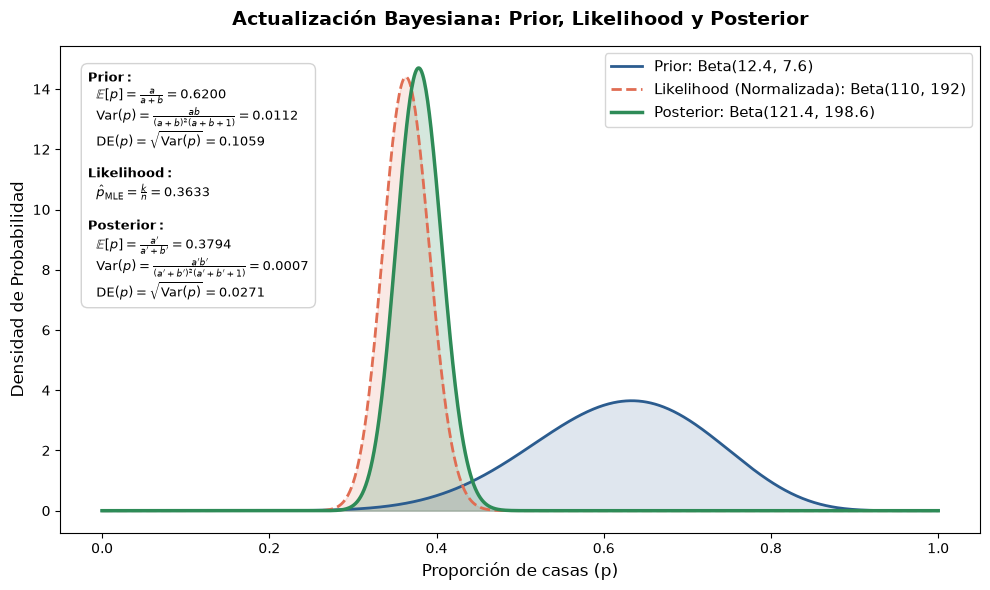

In [56]:
e_prior = a_prior / (a_prior + b_prior)
var_prior = (a_prior * b_prior) / (((a_prior + b_prior)**2) * (a_prior + b_prior + 1))

# Verosimilitud (Estimador de Máxima Verosimilitud - MLE)
mle_lik = k / n

# Posterior
e_post = a_post / (a_post + b_post)
var_post = (a_post * b_post) / (((a_post + b_post)**2) * (a_post + b_post + 1))

mu_post = a_post / (a_post + b_post)
x = np.linspace(0, 1, 1000)

# Configuración de la figura
plt.figure(figsize=(10, 6))

# Trazado de las curvas con Seaborn
sns.lineplot(x=x, y=prior.pdf(x), label=f"Prior: Beta({a_prior}, {b_prior})", color="#2b5c8f", linewidth=2)
sns.lineplot(x=x, y=likelihood.pdf(x), label=f"Likelihood (Normalizada): Beta({k+1}, {n-k+1})", color="#e06d53", linewidth=2, linestyle="--")
sns.lineplot(x=x, y=posterior.pdf(x), label=f"Posterior: Beta({a_post}, {b_post})", color="#2e8b57", linewidth=2.5)

# Sombreado bajo las curvas
plt.fill_between(x, prior.pdf(x), alpha=0.15, color="#2b5c8f")
plt.fill_between(x, likelihood.pdf(x), alpha=0.15, color="#e06d53")
plt.fill_between(x, posterior.pdf(x), alpha=0.2, color="#2e8b57")

# Recuadro con fórmulas y valores estimados (esquina superior izquierda)
stats_text = (
    r"$\mathbf{Prior:}$" "\n"
    rf"  $\mathbb{{E}}[p] = \frac{{a}}{{a+b}} = {e_prior:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(p) = \frac{{ab}}{{(a+b)^2(a+b+1)}} = {var_prior:.4f}$" "\n"
    rf"  $\mathrm{{DE}}(p) = \sqrt{{\mathrm{{Var}}(p)}} = {np.sqrt(var_prior):.4f}$" "\n\n"
    r"$\mathbf{Likelihood:}$" "\n"
    rf"  $\hat{{p}}_{{\mathrm{{MLE}}}} = \frac{{k}}{{n}} = {mle_lik:.4f}$" "\n\n"
    r"$\mathbf{Posterior:}$" "\n"
    rf"  $\mathbb{{E}}[p] = \frac{{a'}}{{a'+b'}} = {e_post:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(p) = \frac{{a'b'}}{{(a'+b')^2(a'+b'+1)}} = {var_post:.4f}$" "\n"
    rf"  $\mathrm{{DE}}(p) = \sqrt{{\mathrm{{Var}}(p)}} = {np.sqrt(var_post):.4f}$"
)

plt.gca().text(
    0.03, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=9.5,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#cccccc", alpha=0.85)
)

# Detalles del gráfico
plt.title("Actualización Bayesiana: Prior, Likelihood y Posterior", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Proporción de casas (p)", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

Como era de esperar la información observada redujo de manera considerable la incertidumbre sobre la proporción de casas en la muestra, lo cual implica una mayor certidumbre sobre este parametro.

### Intervalos Credibilidad

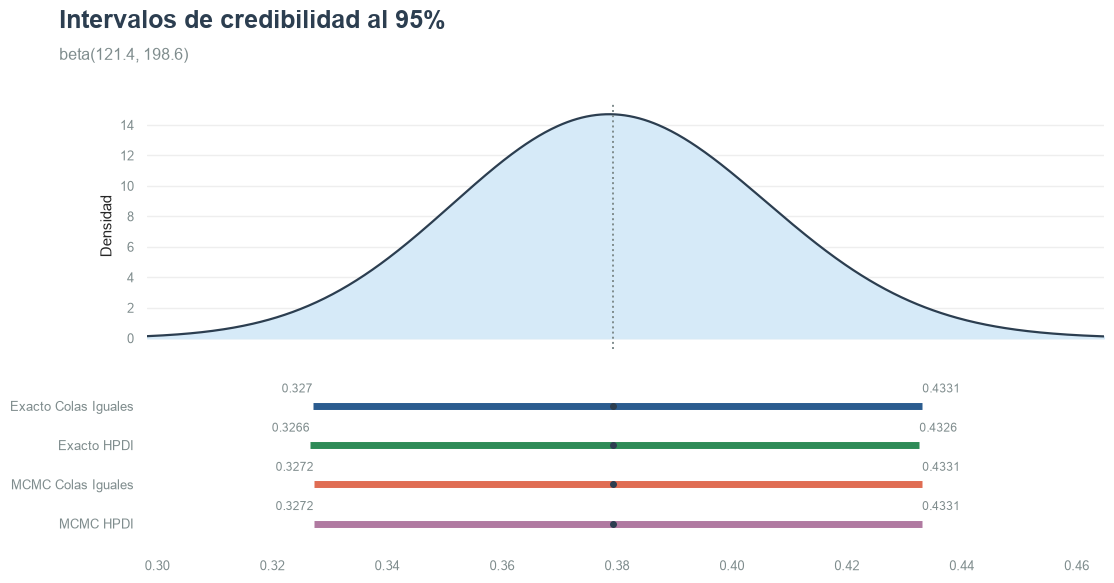

,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.327046,0.433132,0.106086
1,Exacto,HPDI,0.95,0.326552,0.432620,0.106068
2,MCMC,Colas Iguales,0.95,0.327217,0.433122,0.105905
3,MCMC,HPDI,0.95,0.327211,0.433102,0.105891


In [57]:
credible_intervals(posterior, plot=True)

### Predictivas

con m = 150 y x_new = 70

In [58]:
def get_pred_binom(alpha, beta, x_new, m, only_res = False):
    alpha_pred = x_new + alpha
    beta_pred = beta + m - x_new
    normalize_term = math.comb(m, x_new)
    prob = normalize_term * ((special.beta(alpha_pred, beta_pred)) / (special.beta(alpha, beta)))
    expected_value = m * (alpha / (alpha + beta))
    if only_res:
        return prob
    return {
        'prob': float(prob),
        'alpha_pred' : float(alpha_pred),
        'beta_pred' : float(beta_pred),
        'expected_value': float(expected_value),
    }

#### Prior

In [59]:
priores = get_pred_binom(a_prior, b_prior, 70, 150)
print(f"E(X̃) = m·a/(a+b) = 150·{a_prior}/({a_prior}+{b_prior}) = {priores['expected_value']:.4f}")
priores

E(X̃) = m·a/(a+b) = 150·12.4/(12.4+7.6) = 93.0000


{'prob': 0.00930200808535001,
 'alpha_pred': 82.4,
 'beta_pred': 87.6,
 'expected_value': 93.0}

#### Posterior

In [60]:
posteriores = get_pred_binom(a_post, b_post, 70, 150)
print(f"E(X̃) = m·a/(a+b) = 150·{a_post}/({a_post}+{b_post}) = {posteriores['expected_value']:.4f}")
posteriores

E(X̃) = m·a/(a+b) = 150·121.4/(121.4+198.6) = 56.9062


{'prob': 0.010699020877872467,
 'alpha_pred': 191.4,
 'beta_pred': 278.6,
 'expected_value': 56.90625}

### Interpretación General

Note como la información observada en la base de datos recolectada contradijo en cierta medida a aquella sustraida del DANE, pues mientras el DANE reportaba para 2018 una proporción de casas cercana al 60% (hogar habitado), al actualizar dicha muestra con la información recolectadada de FincaRaiz.com en 2026, dicha proporción esperada se reduce aproximanadamente a un 30%.

Esto se traduce en una reduccion considerable en la proporcion de csas, sin embargo es importante mencionara que la prior se baso en el tipo de vivienda ocupada mas comun y solo se usa como proxy de las viviendas vendidas, esto ya que no fue posible hallar dicha información de manera directa.

Asimismo los intervalos calculados son consistentemente estrechos y en genral sugieren que con un 95% de probabilidad la proporción de casas ronda entre 0.32 y 0.43.

# Multinomial dirichlet



## Para `price_amount` (discretizado), toda Bogota
Los precios se discretizan con los umbrales en salarios mínimos de Guerrero (2025), convertidos a pesos con el SMMLV de 2024 ($1.300.000): Económico agrupa los segmentos VIP y VIS (15–135 SMMLV), Normal los segmentos 3 y 4 (135–775 SMMLV) y Lujo los segmentos 5 a 7 (más de 775 SMMLV). 

El corte de 135 SMMLV coincide con el tope legal de la Vivienda de Interés Social. El prior se calibra con la Tabla 3 de ese estudio, que a partir del Censo de Edificaciones (DANE / Coordenada Urbana) reporta 66.119 unidades de vivienda producidas en el Borde Metropolitano de Bogotá en 2006, 2009 y 2013; las proporciones a priori son la participación de cada grupo en ese total (69,3% / 23,6% / 7,1%), escaladas a α₀ = 100.

**Cortes (SMMLV 2024 = $1.300.000):**

| Categoría | Segmentos | Rango SMMLV | Rango COP |
| :--- | :--- | :--- | :--- |
| **Económico** | S1 + S2 | 15 – 135 | \$19,5M – \$175,5M |
| **Normal** | S3 + S4 | 135 – 775 | \$175,5M – \$1.007,5M |
| **Lujo** | S5 + S6 + S7 | > 775 | > \$1.007,5M |

**Tabla de cálculo ($\alpha_j = \alpha_0 \cdot p_j, \alpha_0 = 100$):**

| Categoría | Cálculo | Unidades | $p_j$ | $\alpha_j$ |
| :--- | :--- | :--- | :--- | :--- |
| **Económico** | $10.234 + 35.617$ | $45.851$ | $0{,}6935$ | $69{,}35$ |
| **Normal** | $10.781 + 4.805$ | $15.586$ | $0{,}2357$ | $23{,}57$ |
| **Lujo** | $2.707 + 1.626 + 349$ | $4.682$ | $0{,}0708$ | $7{,}08$ |
| **Total** | | **66.119** | **1** | **100** |

<br>

> Guerrero Hurtado, A. (2025). Concentración de capital para la producción de vivienda en el Borde Metropolitano de Bogotá: un enfoque multiescalar del oligopolio inmobiliario. *Bitácora Urbano Territorial*, *35*(3). https://doi.org/10.15446/bitacora.v35n2.122787

>acceso alternativo: https://dialnet.unirioja.es/servlet/articulo?codigo=10491834

In [61]:
df_diric = df.copy()
SMMLV_2024 = 1_300_000

def clasificador_precios(col):
    if pd.isna(col):
        return np.nan
    s = col / SMMLV_2024
    if s < 15:
        return np.nan          # fuera del rango del paper
    if s <= 135:
        return "Economico"
    elif s <= 775:
        return "Normal"
    return "Lujo"

# crear categorias


df_diric["categorias"] = df_diric["price_amount"].apply(clasificador_precios)

muestra = df_diric["categorias"].sample(n=300, random_state=42)

# prior: Tabla 3 de Guerrero (2025), 2006-09 + 2013
uds = np.array([10234 + 35617,          # S1 + S2
                10781 + 4805,           # S3 + S4
                2707 + 1626 + 349])     # S5 + S6 + S7
a0_prior = 100
alpha_prior = a0_prior * uds / uds.sum()

# observado

x = muestra.value_counts().reindex(["Economico", "Normal", "Lujo"], fill_value=0).to_numpy()
n = np.sum(x)
# posterior

alpha_post = alpha_prior + x
a0_post = np.sum(alpha_post)


### Especificación del modelo

Categorías (precio discretizado), en orden $j$ = 1: Económico, 2: Normal, 3: Lujo.

**Verosimilitud.** Conteos observados en $n = 300$: $\mathbf{x} = (4, 192, 104)$.

$$\mathbf{X} \mid \boldsymbol{\theta} \sim \text{Multinomial}(n = 300;\ \theta_1, \dots, \theta_{3})$$

$$p(\mathbf{x} \mid \boldsymbol{\theta}) = \frac{n!}{\prod_{j} x_j!}\prod_{j=1}^{3}\theta_j^{x_j} = \frac{300!}{4!\,192!\,104!}\;\theta_{1}^{4}\,\theta_{2}^{192}\,\theta_{3}^{104}$$

**Prior.**

$$\boldsymbol{\theta} \sim \text{Dirichlet}(69{,}35;\ 23{,}57;\ 7{,}08), \qquad \alpha_0 = \textstyle\sum_j \alpha_j = 100$$

$$p(\boldsymbol{\theta}) = \frac{\Gamma(\alpha_0)}{\prod_j \Gamma(\alpha_j)}\prod_{j=1}^{3}\theta_j^{\alpha_j - 1} = \frac{\Gamma(100)}{\Gamma(69{,}35)\Gamma(23{,}57)\Gamma(7{,}08)}\;\theta_{1}^{68{,}35}\,\theta_{2}^{22{,}57}\,\theta_{3}^{6{,}08}$$

con $\theta_j \ge 0$ y $\sum_j \theta_j = 1$.

**Posterior.** $p(\boldsymbol{\theta} \mid \mathbf{x}) \propto \prod_j \theta_j^{x_j + \alpha_j - 1}$, el núcleo de una Dirichlet con $\alpha_j' = \alpha_j + x_j$:

$$\begin{aligned}
\alpha_{1}' &= 69{,}35 + 4 = 73{,}35 \\
\alpha_{2}' &= 23{,}57 + 192 = 215{,}57 \\
\alpha_{3}' &= 7{,}08 + 104 = 111{,}08 \\
\alpha_0' &= \alpha_0 + n = 100 + 300 = 400
\end{aligned}$$

$$\boldsymbol{\theta} \mid \mathbf{x} \sim \text{Dirichlet}(73{,}35;\ 215{,}57;\ 111{,}08)$$

$$p(\boldsymbol{\theta} \mid \mathbf{x}) = \frac{\Gamma(400)}{\Gamma(73{,}35)\Gamma(215{,}57)\Gamma(111{,}08)}\;\theta_{1}^{72{,}35}\,\theta_{2}^{214{,}57}\,\theta_{3}^{110{,}08}$$

In [62]:
alpha_prior

array([69.34617886, 23.57264931,  7.08117183])

In [63]:
n

np.int64(300)

In [64]:
x.sum()

np.int64(300)

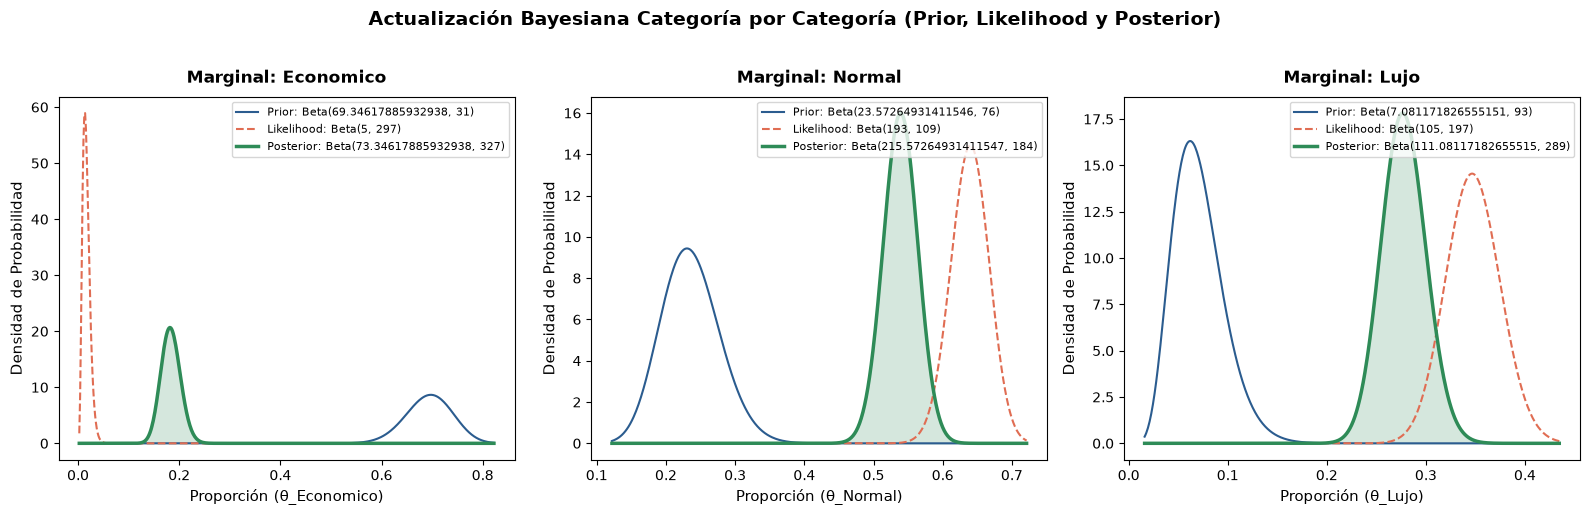

RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA
Fórmulas:
  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)] | DE(θ) = √Var(θ)
  • Likelihood: θ_MLE = k / n
  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)] | DE(θ) = √Var(θ)
--------------------------------------------------------------------------------

Categoría: ECONOMICO
  [Prior]     E[θ] = 0.6935  |  Var(θ) = 0.002105  |  DE(θ) = 0.0459
  [Likelihood] θ_MLE = 0.0133
  [Posterior] E[θ] = 0.1834  |  Var(θ) = 0.000373  |  DE(θ) = 0.0193

Categoría: NORMAL
  [Prior]     E[θ] = 0.2357  |  Var(θ) = 0.001784  |  DE(θ) = 0.0422
  [Likelihood] θ_MLE = 0.6400
  [Posterior] E[θ] = 0.5389  |  Var(θ) = 0.000620  |  DE(θ) = 0.0249

Categoría: LUJO
  [Prior]     E[θ] = 0.0708  |  Var(θ) = 0.000651  |  DE(θ) = 0.0255
  [Likelihood] θ_MLE = 0.3467
  [Posterior] E[θ] = 0.2777  |  Var(θ) = 0.000500  |  DE(θ) = 0.0224


In [65]:
categorias = ["Economico", "Normal", "Lujo"]

# Creación de la figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Estructuras para almacenar los resultados numéricos
res_prior, res_lik, res_post = [], [], []

for i, (cat, ax) in enumerate(zip(categorias, axes)):
    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pri_dist = beta(a_pri, b_pri)
    lik_dist = beta(a_lik, b_lik)
    pos_dist = beta(a_pos, b_pos)

    # Rango de x
    low = min(pri_dist.ppf(0.001), lik_dist.ppf(0.001), pos_dist.ppf(0.001))
    high = max(pri_dist.ppf(0.999), lik_dist.ppf(0.999), pos_dist.ppf(0.999))
    x_axis = np.linspace(max(0, low), min(1, high), 500)

    # Trazado de las curvas
    sns.lineplot(x=x_axis, y=pri_dist.pdf(x_axis), ax=ax, label=f"Prior: Beta({a_pri}, {b_pri:.0f})", color="#2b5c8f", lw=1.5)
    sns.lineplot(x=x_axis, y=lik_dist.pdf(x_axis), ax=ax, label=f"Likelihood: Beta({a_lik}, {b_lik})", color="#e06d53", linestyle="--", lw=1.5)
    sns.lineplot(x=x_axis, y=pos_dist.pdf(x_axis), ax=ax, label=f"Posterior: Beta({a_pos}, {b_pos:.0f})", color="#2e8b57", lw=2.5)

    # Sombreado bajo la posterior
    ax.fill_between(x_axis, pos_dist.pdf(x_axis), alpha=0.2, color="#2e8b57")

    # Formato del gráfico
    ax.set_title(f"Marginal: {cat}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"Proporción (θ_{cat})", fontsize=11)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

    # --- CÁLCULO DE ESTADÍSTICOS ---
    e_pri = a_pri / (a_pri + b_pri)
    var_pri = (a_pri * b_pri) / (((a_pri + b_pri)**2) * (a_pri + b_pri + 1))

    mle_lik = k_i / n

    e_pos = a_pos / (a_pos + b_pos)
    var_pos = (a_pos * b_pos) / (((a_pos + b_pos)**2) * (a_pos + b_pos + 1))

    # Guardar métricas calculadas
    res_prior.append((e_pri, var_pri))
    res_lik.append(mle_lik)
    res_post.append((e_pos, var_pos))

plt.suptitle("Actualización Bayesiana Categoría por Categoría (Prior, Likelihood y Posterior)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- IMPRESIÓN CON FÓRMULAS Y VALORES DEBAJO DEL GRÁFICO ---
print("=" * 80)
print("RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA")
print("=" * 80)
print("Fórmulas:")
print("  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)] | DE(θ) = √Var(θ)")
print("  • Likelihood: θ_MLE = k / n")
print("  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)] | DE(θ) = √Var(θ)")
print("-" * 80)

for i, cat in enumerate(categorias):
    e_pri, var_pri = res_prior[i]
    mle_lik = res_lik[i]
    e_pos, var_pos = res_post[i]

    print(f"\nCategoría: {cat.upper()}")
    print(f"  [Prior]     E[θ] = {e_pri:.4f}  |  Var(θ) = {var_pri:.6f}  |  DE(θ) = {np.sqrt(var_pri):.4f}")
    print(f"  [Likelihood] θ_MLE = {mle_lik:.4f}")
    print(f"  [Posterior] E[θ] = {e_pos:.4f}  |  Var(θ) = {var_pos:.6f}  |  DE(θ) = {np.sqrt(var_pos):.4f}")

print("=" * 80)

### Intervalos

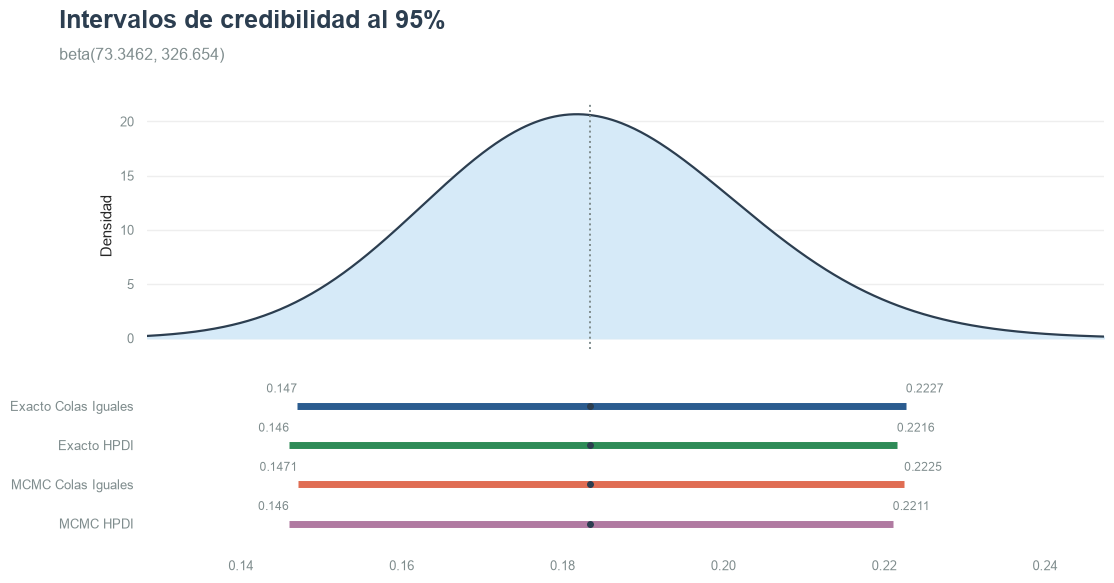

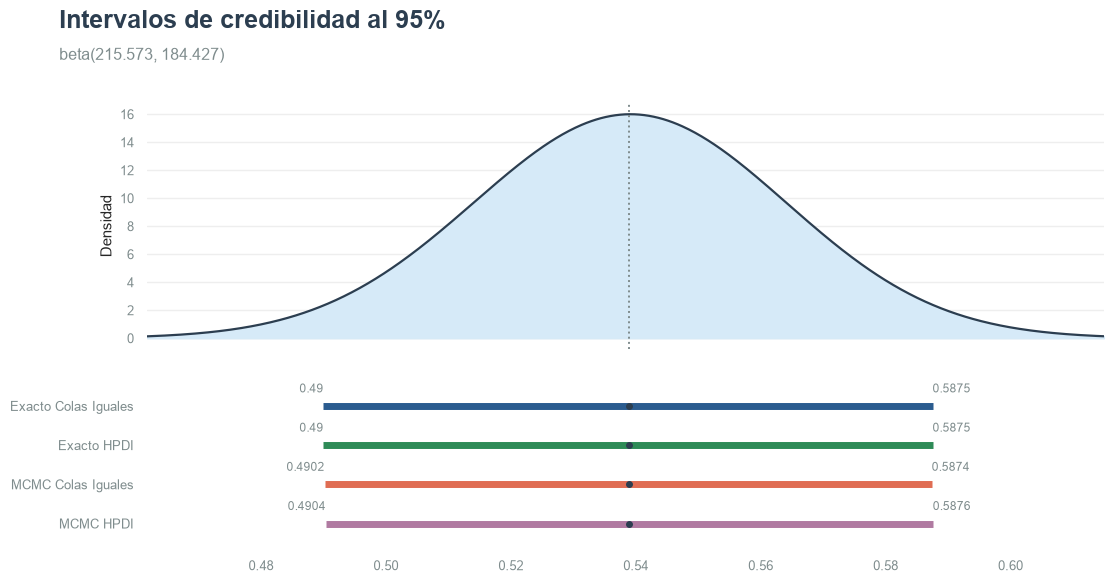

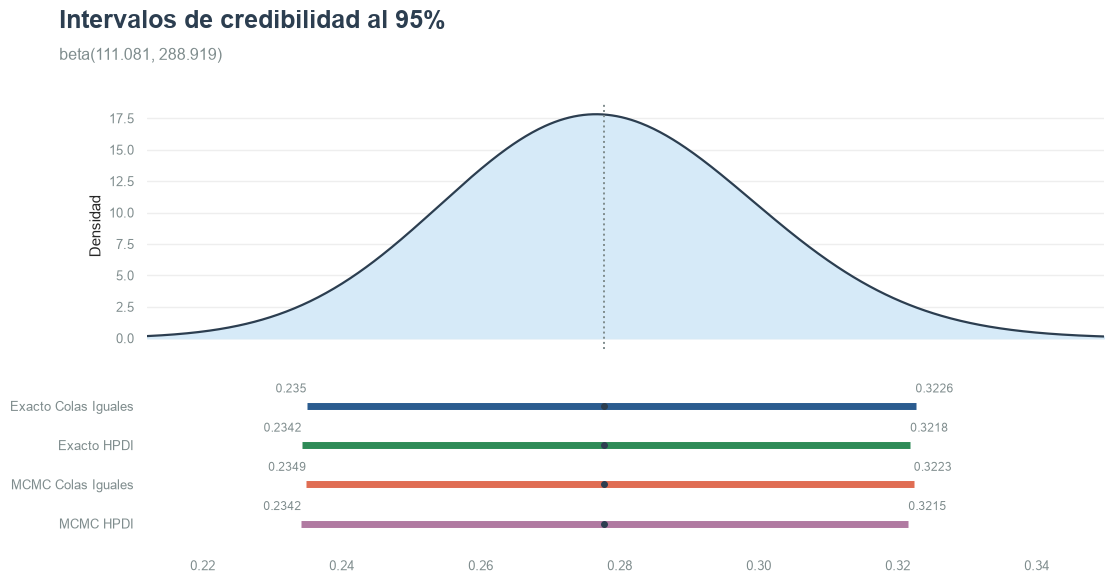

In [66]:
informe_intervalos = {}
for i, (cat) in enumerate(categorias):
    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pos_dist = beta(a_pos, b_pos)

    informe_intervalos[cat] = credible_intervals(pos_dist, plot=True)

In [67]:
for k, v in informe_intervalos.items():
    print("="*20)
    print(k)
    print("="*20)
    display(v)

Economico


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.147032,0.222697,0.075665
1,Exacto,HPDI,0.95,0.146034,0.221586,0.075551
2,MCMC,Colas Iguales,0.95,0.147054,0.222485,0.075432
3,MCMC,HPDI,0.95,0.145997,0.221069,0.075072


Normal


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.489984,0.587511,0.097527
1,Exacto,HPDI,0.95,0.489984,0.587511,0.097527
2,MCMC,Colas Iguales,0.95,0.490158,0.587383,0.097225
3,MCMC,HPDI,0.95,0.490362,0.587553,0.097191


Lujo


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.234953,0.322558,0.087605
1,Exacto,HPDI,0.95,0.234236,0.321793,0.087557
2,MCMC,Colas Iguales,0.95,0.234893,0.322316,0.087424
3,MCMC,HPDI,0.95,0.234191,0.321529,0.087338


### Predictivas

In [68]:
def get_pred_dirichlet_multinomial(
    alpha, x=None, k=None, n_tilde=1, only_res=False
):
    """Calcula las probabilidades predictivas individuales y el valor esperado

    para un nuevo experimento de n_tilde observaciones bajo el modelo
    Multinomial-Dirichlet.

    Parámetros:
    - alpha: array-like, vector de hiperparámetros a priori alpha_k.
    - k: int (opcional), índice de una categoría específica. Si es None,
    retorna para todas.
    - n_tilde: int, número de nuevos ensayos futuros (por defecto 1).
    """
    alpha = np.array(alpha, dtype=float)

    # Si se pasan conteos observados x, actualizamos a los parámetros posteriores
    if x is not None:
        x = np.array(x, dtype=float)
        alpha_post = alpha + x
    else:
        alpha_post = alpha

    # alpha_0 es la suma de los parametros alpha (posteriores o priores)
    alpha_0_post = np.sum(alpha_post)

    # Probabilidad individual de la próxima observación (n_tilde = 1)
    probs = alpha_post / alpha_0_post

    # Esperanza del número de ocurrencias en n_tilde observaciones
    expected_values = n_tilde * probs

    if k is not None:
        probs = probs[k]
        expected_values = expected_values[k]

    if only_res:
        return probs

    return {
        'prob_individual': probs,
        'expected_value': expected_values,
        'alpha_post': alpha_post,
        'alpha_0_post': alpha_0_post,
    }

#### Prior

In [69]:
res = get_pred_dirichlet_multinomial(alpha_prior, n_tilde=50)
for cat, a_j, e in zip(categorias, res['alpha_post'], res['expected_value']):
    print(f"E(X̃_{cat}) = ñ·α_j/α_0 = 50·{a_j:.2f}/{res['alpha_0_post']:.2f} = {e:.4f}")

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados.drop(columns=['Conteo_x', 'Alpha_Post'])

E(X̃_Economico) = ñ·α_j/α_0 = 50·69.35/100.00 = 34.6731
E(X̃_Normal) = ñ·α_j/α_0 = 50·23.57/100.00 = 11.7863
E(X̃_Lujo) = ñ·α_j/α_0 = 50·7.08/100.00 = 3.5406


,Categoria,Alpha_Prior,Prob_Individual,Valor_Esperado_n50
0,Economico,69.346179,0.693462,34.673089
1,Normal,23.572649,0.235726,11.786325
2,Lujo,7.081172,0.070812,3.540586


#### Posterior

In [70]:
res = get_pred_dirichlet_multinomial(alpha_prior, x=x, n_tilde=50)
for cat, a_j, e in zip(categorias, res['alpha_post'], res['expected_value']):
    print(f"E(X̃_{cat}) = ñ·α_j/α_0 = 50·{a_j:.2f}/{res['alpha_0_post']:.2f} = {e:.4f}")

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados

E(X̃_Economico) = ñ·α_j/α_0 = 50·73.35/400.00 = 9.1683
E(X̃_Normal) = ñ·α_j/α_0 = 50·215.57/400.00 = 26.9466
E(X̃_Lujo) = ñ·α_j/α_0 = 50·111.08/400.00 = 13.8851


,Categoria,Alpha_Prior,Conteo_x,Alpha_Post,Prob_Individual,Valor_Esperado_n50
0,Economico,69.346179,4,73.346179,0.183365,9.168272
1,Normal,23.572649,192,215.572649,0.538932,26.946581
2,Lujo,7.081172,104,111.081172,0.277703,13.885146


### Interpretación General

De manera general la varianza posterior es menor que la prior, sin embargo al comparar los datos prior y los observados se ve que en general la tendencia cambia, pues en la muestra recolectada las viviendas que se calcificaron como lujo eran mas comunes que aqullas calicificadas como economicas y ademas se aumento ligeramente, esto constituye un fuerte cambio en el ordenamiento, pues la categoria Economico pasa de ser la mas comun a la menos comun, esto posiblemente a medidas como la prohibición de venta de viviendas VIS en los primeros años de ser adquirida.Ademas el efecto del cambio de tendencia se hace mucho mas evidente al observar los valores esperados con n = 50 de las predictivas; esto ya que la prior indica que la categoria mas comun será economica, mientras que la categoria menos comun será lujo. Cosa contraria a lo que indica la predictiva posterior que muestra que la mas comun será la categoria normal y la menos comun Economica.

Esto se traduce en intervalos que con un 95% de probabilidad afirman que la clase menos comun es Economica, seguinda de Lujo, esto sin que dichos intervalos sesolapen (esto en todos los metodos evaluados).




## Para `property_type`

El prior se calibra con el estudio de la Unidad Administrativa Especial de Catastro Distrital (UAECD) y Fincaraíz sobre vivienda usada en las siete principales aglomeraciones del país, que sobre 1.351.073 ofertas reporta, para el segmento de venta, una composición de 68% apartamentos, 30% casas y 2% apartaestudios.

Para compensar la falta de casa campestre, habitación y finca se les reparte el 1%  del conteo total que se desea tener, por lo tanto el alpha prior se define como:

$$\begin{pmatrix} \alpha_{\text{apartamento}} \\ \alpha_{\text{casa}} \\ \alpha_{\text{apartaestudio}} \\ \alpha_{\text{casa\_camp}} \\ \alpha_{\text{hab}} \\ \alpha_{\text{finca}} \end{pmatrix} = \begin{pmatrix} 100.98 \\ 44.55 \\ 2.97 \\ 0.5 \\ 0.5 \\ 0.5 \end{pmatrix}$$

de esta manera construyendo una prior informatva, frente a la sub muestra de 300 que se tomará del dataframe.

| Categoría | $p_j$ | $\alpha_j = 150 \cdot p_j$ |
| :--- | :--- | :--- |
| **apartamento** | $0{,}99 \times 0{,}68 = 0{,}6732$ | $100{,}98$ |
| **casa** | $0{,}99 \times 0{,}30 = 0{,}2970$ | $44{,}55$ |
| **apartaestudio** | $0{,}99 \times 0{,}02 = 0{,}0198$ | $2{,}97$ |
| **casa_campestre** | $0{,}01 / 3 \approx 0{,}003333$ | $0{,}50$ |
| **habitacion** | $0{,}01 / 3 \approx 0{,}003333$ | $0{,}50$ |
| **finca** | $0{,}01 / 3 \approx 0{,}003333$ | $0{,}50$ |
| **Total** | **1** | **150** |


https://www.catastrobogota.gov.co/noticia/fincaraiz-presento-la-perspectiva-del-mercado-inmobiliario-en-colombia

In [71]:
dummy_cols = [col for col in df.columns if col.startswith("property_type_")]
# recuperar la columna property_type para usar con multinomial
df["property_type"] = (
    df[dummy_cols]
    .idxmax(axis=1)
    .str.replace("property_type_", "")
    .where(df[dummy_cols].sum(axis=1) == 1, "apartamento")
)

In [72]:
# orden: apartamento, casa, apartaestudio, casa_campestre, habitacion, finca
alpha_prior = np.array([100.98, 44.55, 2.97, 0.50, 0.50, 0.50])   # a0 = 150

a0_prior = np.sum(alpha_prior)

# observado
muestra = df["property_type"].sample(n=300, random_state=42)
x = muestra.value_counts().reindex(
    ["apartamento", "casa", "apartaestudio", "casa_campestre", "habitacion", "finca"],
    fill_value=0
    ).to_numpy()

n = np.sum(x)

# posterior
alpha_post = alpha_prior + x
a0_post = np.sum(alpha_post)

### Especificación del modelo

Categorías (tipo de inmueble), en orden $j$ = 1: apartamento, 2: casa, 3: apartaestudio, 4: casa campestre, 5: habitación, 6: finca.

**Verosimilitud.** Conteos observados en $n = 300$: $\mathbf{x} = (166, 109, 24, 1, 0, 0)$.

$$\mathbf{X} \mid \boldsymbol{\theta} \sim \text{Multinomial}(n = 300;\ \theta_1, \dots, \theta_{6})$$

$$p(\mathbf{x} \mid \boldsymbol{\theta}) = \frac{n!}{\prod_{j} x_j!}\prod_{j=1}^{6}\theta_j^{x_j} = \frac{300!}{166!\,109!\,24!\,1!\,0!\,0!}\;\theta_{1}^{166}\,\theta_{2}^{109}\,\theta_{3}^{24}\,\theta_{4}^{1}\,\theta_{5}^{0}\,\theta_{6}^{0}$$

**Prior.**

$$\boldsymbol{\theta} \sim \text{Dirichlet}(100{,}98;\ 44{,}55;\ 2{,}97;\ 0{,}5;\ 0{,}5;\ 0{,}5), \qquad \alpha_0 = \textstyle\sum_j \alpha_j = 150$$

$$p(\boldsymbol{\theta}) = \frac{\Gamma(\alpha_0)}{\prod_j \Gamma(\alpha_j)}\prod_{j=1}^{6}\theta_j^{\alpha_j - 1} = \frac{\Gamma(150)}{\Gamma(100{,}98)\Gamma(44{,}55)\Gamma(2{,}97)\Gamma(0{,}5)\Gamma(0{,}5)\Gamma(0{,}5)}\;\theta_{1}^{99{,}98}\,\theta_{2}^{43{,}55}\,\theta_{3}^{1{,}97}\,\theta_{4}^{-0{,}5}\,\theta_{5}^{-0{,}5}\,\theta_{6}^{-0{,}5}$$

con $\theta_j \ge 0$ y $\sum_j \theta_j = 1$.

**Posterior.** $p(\boldsymbol{\theta} \mid \mathbf{x}) \propto \prod_j \theta_j^{x_j + \alpha_j - 1}$, el núcleo de una Dirichlet con $\alpha_j' = \alpha_j + x_j$:

$$\begin{aligned}
\alpha_{1}' &= 100{,}98 + 166 = 266{,}98 \\
\alpha_{2}' &= 44{,}55 + 109 = 153{,}55 \\
\alpha_{3}' &= 2{,}97 + 24 = 26{,}97 \\
\alpha_{4}' &= 0{,}5 + 1 = 1{,}5 \\
\alpha_{5}' &= 0{,}5 + 0 = 0{,}5 \\
\alpha_{6}' &= 0{,}5 + 0 = 0{,}5 \\
\alpha_0' &= \alpha_0 + n = 150 + 300 = 450
\end{aligned}$$

$$\boldsymbol{\theta} \mid \mathbf{x} \sim \text{Dirichlet}(266{,}98;\ 153{,}55;\ 26{,}97;\ 1{,}5;\ 0{,}5;\ 0{,}5)$$

$$p(\boldsymbol{\theta} \mid \mathbf{x}) = \frac{\Gamma(450)}{\Gamma(266{,}98)\Gamma(153{,}55)\Gamma(26{,}97)\Gamma(1{,}5)\Gamma(0{,}5)\Gamma(0{,}5)}\;\theta_{1}^{265{,}98}\,\theta_{2}^{152{,}55}\,\theta_{3}^{25{,}97}\,\theta_{4}^{-0{,}5}\,\theta_{5}^{-0{,}5}\,\theta_{6}^{-0{,}5}$$

In [73]:
x/x.sum()

array([0.55333333, 0.36333333, 0.08      , 0.00333333, 0.        ,
       0.        ])

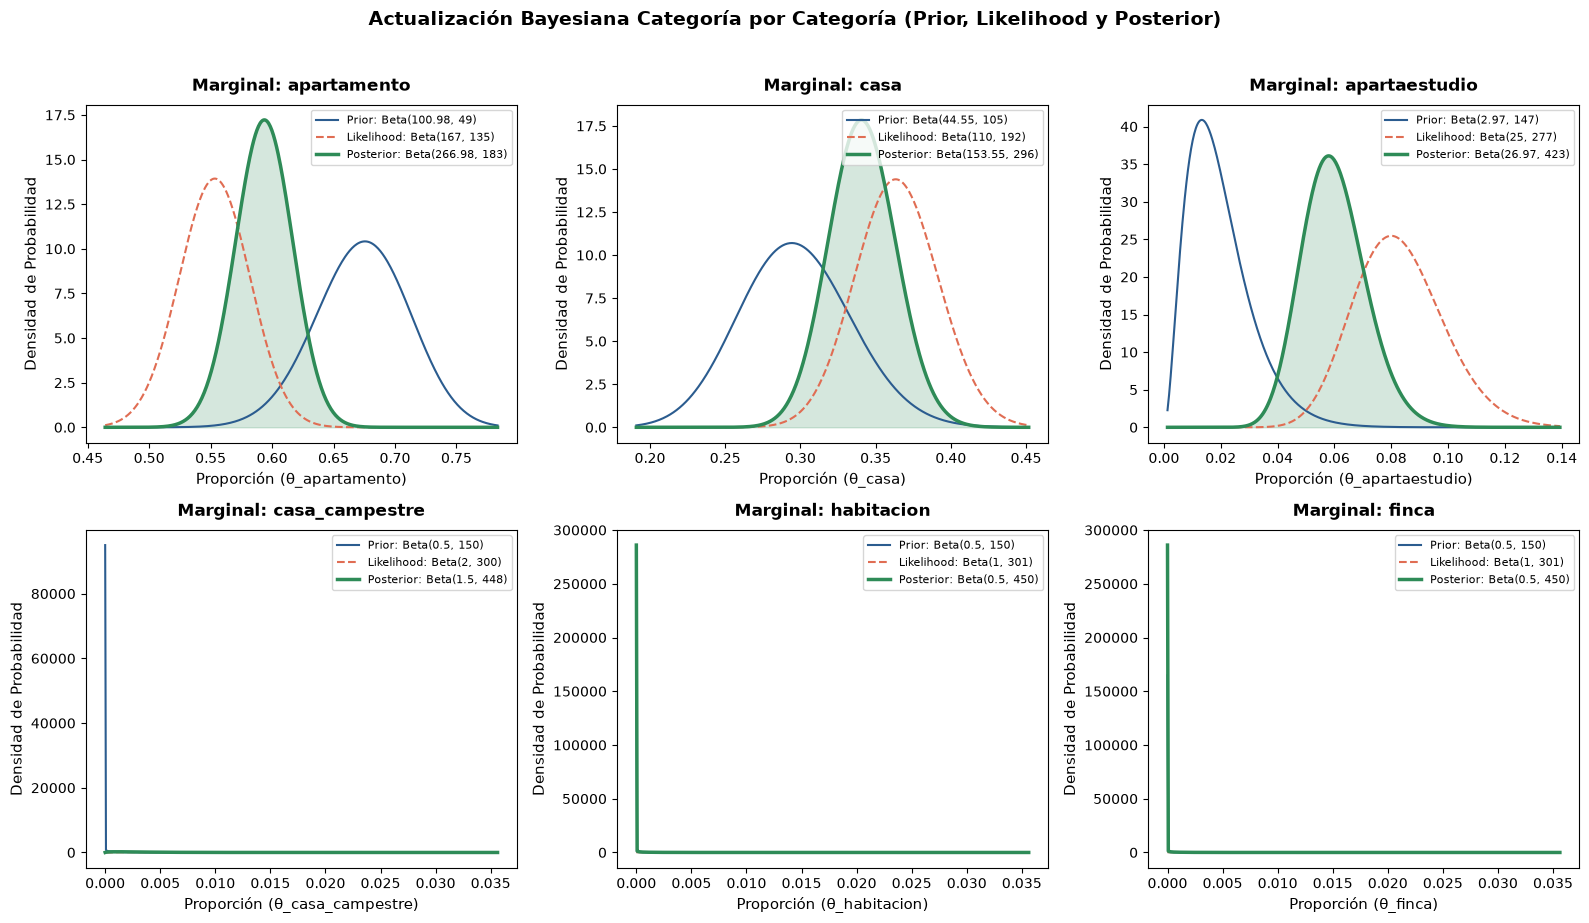

RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA
Fórmulas:
  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)] | DE(θ) = √Var(θ)
  • Likelihood: θ_MLE = k / n
  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)] | DE(θ) = √Var(θ)
--------------------------------------------------------------------------------

Categoría: APARTAMENTO
  [Prior]     E[θ] = 0.6732  |  Var(θ) = 0.001457  |  DE(θ) = 0.0382
  [Likelihood] θ_MLE = 0.5533
  [Posterior] E[θ] = 0.5933  |  Var(θ) = 0.000535  |  DE(θ) = 0.0231

Categoría: CASA
  [Prior]     E[θ] = 0.2970  |  Var(θ) = 0.001383  |  DE(θ) = 0.0372
  [Likelihood] θ_MLE = 0.3633
  [Posterior] E[θ] = 0.3412  |  Var(θ) = 0.000498  |  DE(θ) = 0.0223

Categoría: APARTAESTUDIO
  [Prior]     E[θ] = 0.0198  |  Var(θ) = 0.000129  |  DE(θ) = 0.0113
  [Likelihood] θ_MLE = 0.0800
  [Posterior] E[θ] = 0.0599  |  Var(θ) = 0.000125  |  DE(θ) = 0.0112

Categoría: CASA_CAMPESTRE
  [Prio

In [74]:
categorias = ["apartamento", "casa", "apartaestudio", "casa_campestre", "habitacion", "finca"]
# Creación de la figura con 6 subplots en una cuadrícula 2x3

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Estructuras para almacenar los resultados numéricos
res_prior, res_lik, res_post = [], [], []

# Usamos axes.flat para iterar sobre los 6 ejes de forma unidimensional
for i, (cat, ax) in enumerate(zip(categorias, axes.flat)):
    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pri_dist = beta(a_pri, b_pri)
    lik_dist = beta(a_lik, b_lik)
    pos_dist = beta(a_pos, b_pos)

    # Rango de x
    low = min(pri_dist.ppf(0.001), lik_dist.ppf(0.001), pos_dist.ppf(0.001))
    high = max(pri_dist.ppf(0.999), lik_dist.ppf(0.999), pos_dist.ppf(0.999))
    x_axis = np.linspace(max(0, low), min(1, high), 500)

    # Trazado de las curvas
    sns.lineplot(x=x_axis, y=pri_dist.pdf(x_axis), ax=ax, label=f"Prior: Beta({a_pri}, {b_pri:.0f})", color="#2b5c8f", lw=1.5)
    sns.lineplot(x=x_axis, y=lik_dist.pdf(x_axis), ax=ax, label=f"Likelihood: Beta({a_lik}, {b_lik})", color="#e06d53", linestyle="--", lw=1.5)
    sns.lineplot(x=x_axis, y=pos_dist.pdf(x_axis), ax=ax, label=f"Posterior: Beta({a_pos}, {b_pos:.0f})", color="#2e8b57", lw=2.5)

    # Sombreado bajo la posterior
    ax.fill_between(x_axis, pos_dist.pdf(x_axis), alpha=0.2, color="#2e8b57")

    # Formato del gráfico
    ax.set_title(f"Marginal: {cat}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"Proporción (θ_{cat})", fontsize=11)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

    # --- CÁLCULO DE ESTADÍSTICOS ---
    e_pri = a_pri / (a_pri + b_pri)
    var_pri = (a_pri * b_pri) / (((a_pri + b_pri)**2) * (a_pri + b_pri + 1))

    mle_lik = k_i / n

    e_pos = a_pos / (a_pos + b_pos)
    var_pos = (a_pos * b_pos) / (((a_pos + b_pos)**2) * (a_pos + b_pos + 1))

    # Guardar métricas calculadas
    res_prior.append((e_pri, var_pri))
    res_lik.append(mle_lik)
    res_post.append((e_pos, var_pos))

plt.suptitle("Actualización Bayesiana Categoría por Categoría (Prior, Likelihood y Posterior)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- IMPRESIÓN CON FÓRMULAS Y VALORES DEBAJO DEL GRÁFICO ---
print("=" * 80)
print("RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA")
print("=" * 80)
print("Fórmulas:")
print("  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)] | DE(θ) = √Var(θ)")
print("  • Likelihood: θ_MLE = k / n")
print("  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)] | DE(θ) = √Var(θ)")
print("-" * 80)

for i, cat in enumerate(categorias):
    e_pri, var_pri = res_prior[i]
    mle_lik = res_lik[i]
    e_pos, var_pos = res_post[i]

    print(f"\nCategoría: {cat.upper()}")
    print(f"  [Prior]     E[θ] = {e_pri:.4f}  |  Var(θ) = {var_pri:.6f}  |  DE(θ) = {np.sqrt(var_pri):.4f}")
    print(f"  [Likelihood] θ_MLE = {mle_lik:.4f}")
    print(f"  [Posterior] E[θ] = {e_pos:.4f}  |  Var(θ) = {var_pos:.6f}  |  DE(θ) = {np.sqrt(var_pos):.4f}")

print("=" * 80)

### Invervalos

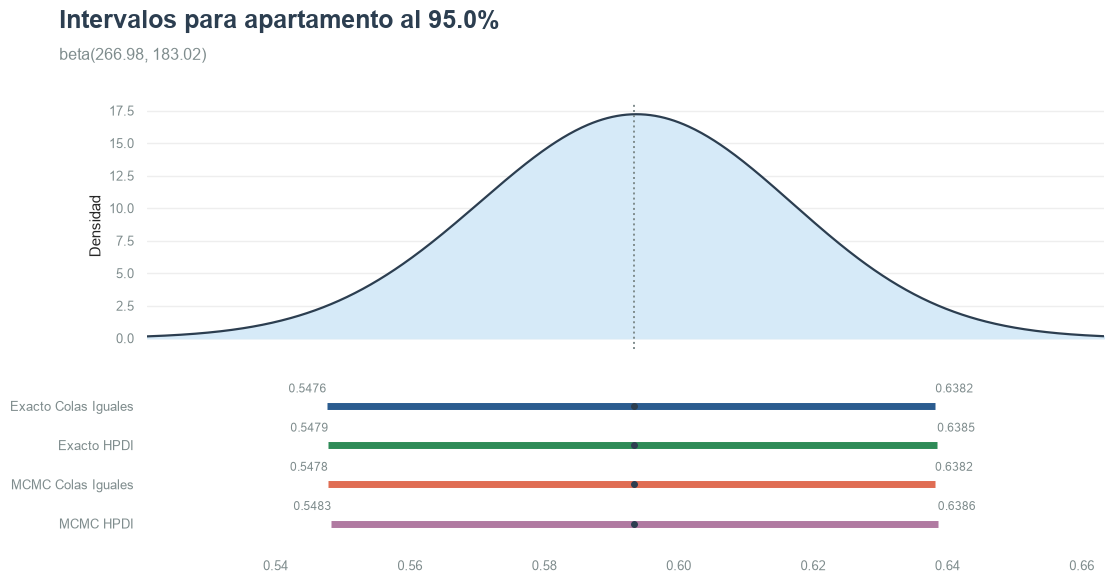

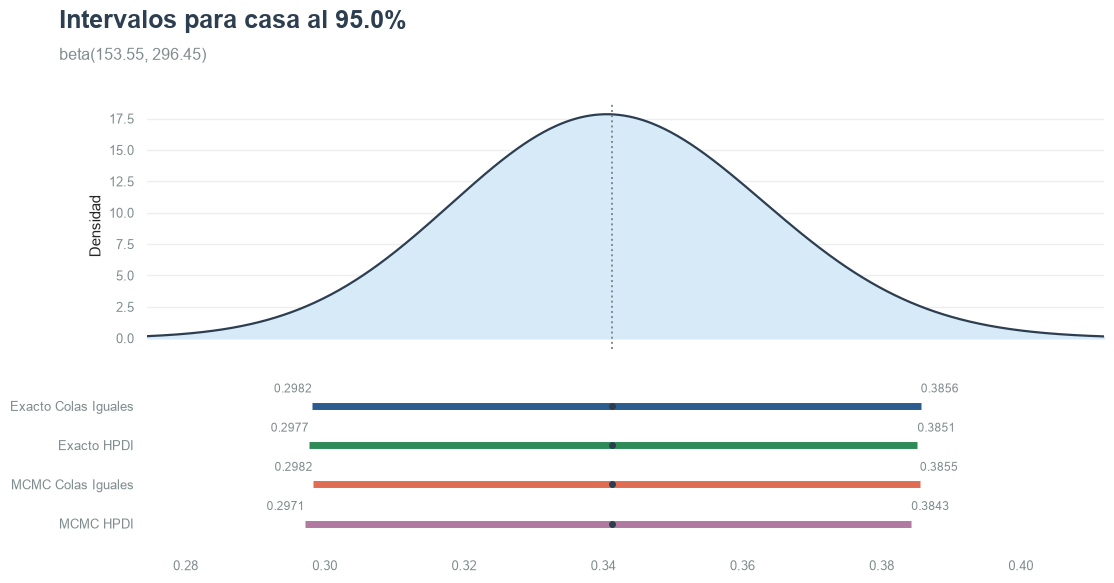

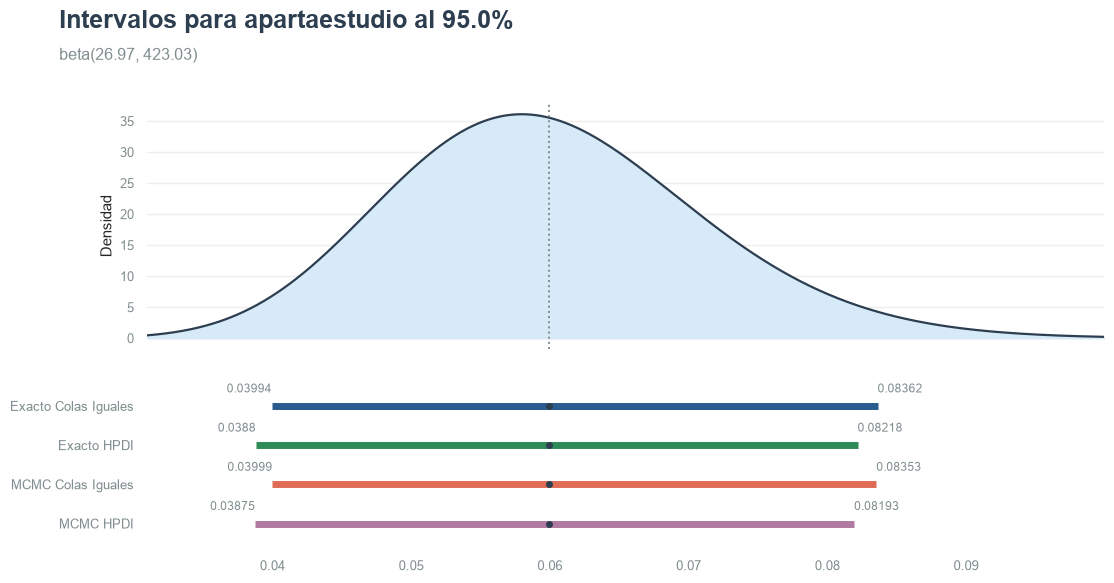

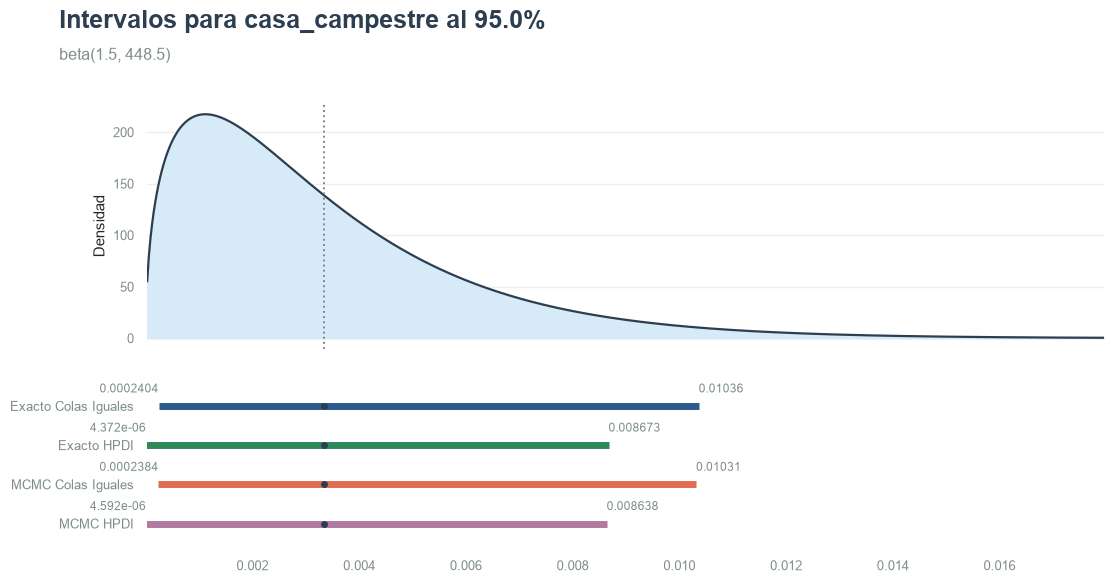

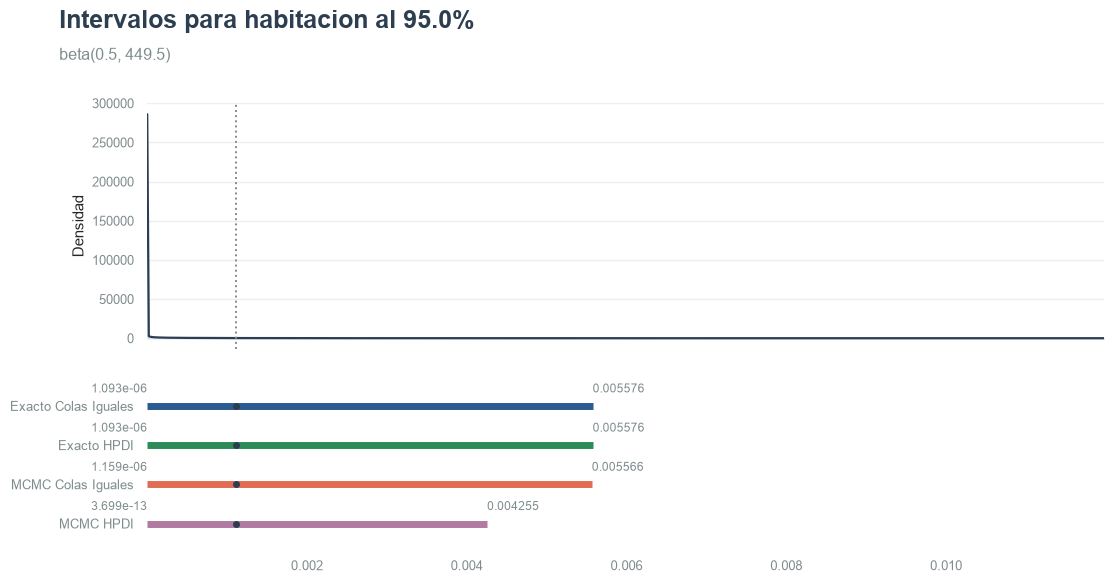

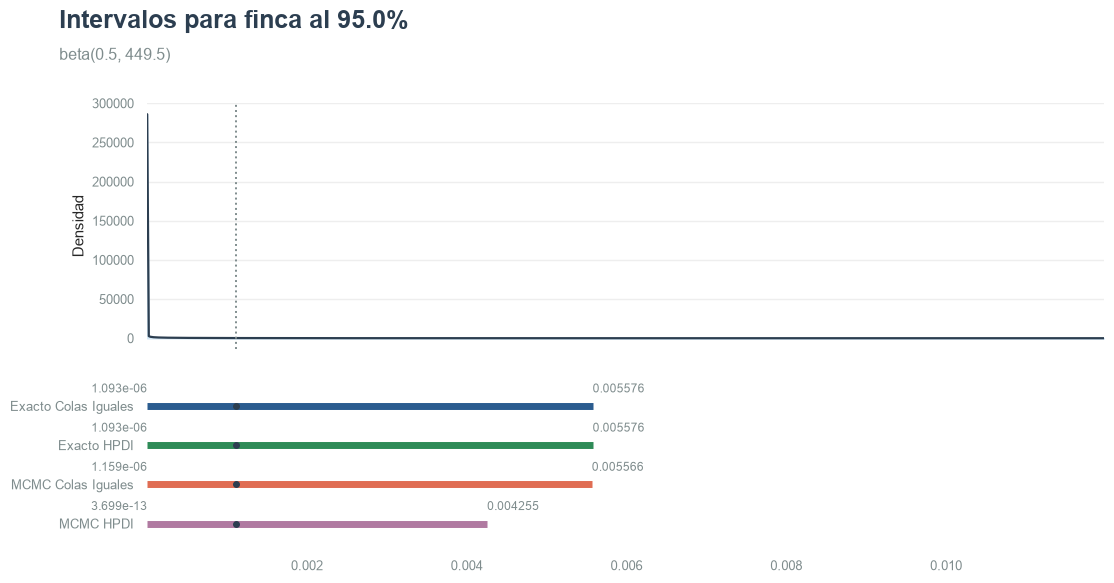

In [75]:
level = 0.95
informe_intervalos = {}
for i, (cat) in enumerate(categorias):
    title = f'Intervalos para {cat} al {level*100}%'

    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pos_dist = beta(a_pos, b_pos)

    informe_intervalos[cat] = credible_intervals(pos_dist, plot=True, title=title)

In [76]:
for k, v in informe_intervalos.items():
    print("="*20)
    print(k)
    print("="*20)
    display(v)

apartamento


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.547583,0.638209,0.090625
1,Exacto,HPDI,0.95,0.547863,0.638482,0.090619
2,MCMC,Colas Iguales,0.95,0.547806,0.638166,0.090360
3,MCMC,HPDI,0.95,0.548313,0.638580,0.090267


casa


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.298158,0.385623,0.087465
1,Exacto,HPDI,0.95,0.297697,0.385142,0.087446
2,MCMC,Colas Iguales,0.95,0.298242,0.385502,0.087259
3,MCMC,HPDI,0.95,0.297097,0.384260,0.087163


apartaestudio


...

,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.000240,0.010362,0.010122
1,Exacto,HPDI,0.95,0.000004,0.008673,0.008668
2,MCMC,Colas Iguales,0.95,0.000238,0.010313,0.010074
3,MCMC,HPDI,0.95,0.000005,0.008638,0.008633


habitacion


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,1.093009e-06,0.005576,0.005575
1,Exacto,HPDI,0.95,1.093009e-06,0.005576,0.005575
2,MCMC,Colas Iguales,0.95,1.159363e-06,0.005566,0.005565
3,MCMC,HPDI,0.95,3.698848e-13,0.004255,0.004255


finca


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,1.093009e-06,0.005576,0.005575
1,Exacto,HPDI,0.95,1.093009e-06,0.005576,0.005575
2,MCMC,Colas Iguales,0.95,1.159363e-06,0.005566,0.005565
3,MCMC,HPDI,0.95,3.698848e-13,0.004255,0.004255


### Predictivas

#### Prior

In [77]:
alpha_prior

array([100.98,  44.55,   2.97,   0.5 ,   0.5 ,   0.5 ])

In [78]:
res = get_pred_dirichlet_multinomial(alpha_prior, n_tilde=50)
for cat, a_j, e in zip(categorias, res['alpha_post'], res['expected_value']):
    print(f"E(X̃_{cat}) = ñ·α_j/α_0 = 50·{a_j:.2f}/{res['alpha_0_post']:.2f} = {e:.4f}")

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados.drop(columns=['Conteo_x', 'Alpha_Post'])

E(X̃_apartamento) = ñ·α_j/α_0 = 50·100.98/150.00 = 33.6600
E(X̃_casa) = ñ·α_j/α_0 = 50·44.55/150.00 = 14.8500
E(X̃_apartaestudio) = ñ·α_j/α_0 = 50·2.97/150.00 = 0.9900
E(X̃_casa_campestre) = ñ·α_j/α_0 = 50·0.50/150.00 = 0.1667
E(X̃_habitacion) = ñ·α_j/α_0 = 50·0.50/150.00 = 0.1667
E(X̃_finca) = ñ·α_j/α_0 = 50·0.50/150.00 = 0.1667


,Categoria,Alpha_Prior,Prob_Individual,Valor_Esperado_n50
0,apartamento,100.98,0.673200,33.660000
1,casa,44.55,0.297000,14.850000
2,apartaestudio,2.97,0.019800,0.990000
3,casa_campestre,0.50,0.003333,0.166667
4,habitacion,0.50,0.003333,0.166667
5,finca,0.50,0.003333,0.166667


#### Posterior

In [79]:
res = get_pred_dirichlet_multinomial(alpha_prior, x=x, n_tilde=50)
for cat, a_j, e in zip(categorias, res['alpha_post'], res['expected_value']):
    print(f"E(X̃_{cat}) = ñ·α_j/α_0 = 50·{a_j:.2f}/{res['alpha_0_post']:.2f} = {e:.4f}")

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados

E(X̃_apartamento) = ñ·α_j/α_0 = 50·266.98/450.00 = 29.6644
E(X̃_casa) = ñ·α_j/α_0 = 50·153.55/450.00 = 17.0611
E(X̃_apartaestudio) = ñ·α_j/α_0 = 50·26.97/450.00 = 2.9967
E(X̃_casa_campestre) = ñ·α_j/α_0 = 50·1.50/450.00 = 0.1667
E(X̃_habitacion) = ñ·α_j/α_0 = 50·0.50/450.00 = 0.0556
E(X̃_finca) = ñ·α_j/α_0 = 50·0.50/450.00 = 0.0556


,Categoria,Alpha_Prior,Conteo_x,Alpha_Post,Prob_Individual,Valor_Esperado_n50
0,apartamento,100.98,166,266.98,0.593289,29.664444
1,casa,44.55,109,153.55,0.341222,17.061111
2,apartaestudio,2.97,24,26.97,0.059933,2.996667
3,casa_campestre,0.50,1,1.50,0.003333,0.166667
4,habitacion,0.50,0,0.50,0.001111,0.055556
5,finca,0.50,0,0.50,0.001111,0.055556


### Interpretación General

De nuevo la certidumbre sobre los parametros estimados aumento de manera consistente, junto a esto se ve que la prior y lo observado coincidieron en la proporción de casas (aumentaron su proporción ligeramente) y apartamentos (disminuyeron su proporción ligeramente), en las clases minoritarias que no reportaba el estudio (y que ademas se les repartio el peso) se mantiene de manera consistente su proporción practicamente despreciable. No obstante el hallazgo mas interesante viene de la proporción de apartaestudios, pues la prior (calculada con datos de 2021) sugiere una proporcion menor a la que se observo en los datos observados, esto sugiere un cambio de tendencia en el mercado hacia dicho tipo de inmueble.

A pesar de este amuento en la oferta de apartaestudios el ranking de los 3 inmuebles mas representativos sigue igual, con los apartementos siendo los mas populares, seguidos por las casas y los apartaestudios; esto se hace mas evidente al observar que los limites de los intevalos de estas 3 clases mantienen ese ordenamiento sin solaparse y tambien al observar que para n = 50 los apartementos siguen presentando el mayor de estos, aunque si se ve un poco disminuido ante un aumento en las casas y apartaestudios.

# Normal Inversa Gamma

## Para `price_amount_log`
(a pesar de no ser normal se usará el modelo normal gamma al ser la herramienta disponible que mejor modela esos datos)

Los hiperparámetros se calibran con Toloza‑Delgado, Melo‑Martínez y Azcárate‑Romero (2021), quienes reportan para 708 proyectos de vivienda en venta en Bogotá (Coordenada Urbana, noviembre de 2019) un precio con primer y tercer cuartil de $214,9M y $504,3M. 

Dado el fuerte sesgo a la derecha de los precios, el modelo se hace sobre el logaritmo del precio. Bajo log‑normalidad, los cuartiles implican una mediana de 19,61 y una desviación estándar logarítmica de 0,632; la mediana se ajusta a pesos de 2024 con la inflación acumulada 2020–2024 (≈39,6%), obteniendo μ₀ = 19,95 (mediana ≈ $459,5M). 

Se fija κ₀ = 10. Para la varianza se usa a₀ = 5  y b₀ = (a₀ − 1)·σ̂² = 1,60, de modo que E[σ²] coincide con la varianza logarítmica de la fuente (σ² ≈ 0,83).

| Parámetro | Valor | Cálculo | Justificación | Fuente |
|---|---|---|---|---|
| $Q_1$, $Q_3$ | 214,9M ; 504,3M | Tomados de la Tabla 2 (miles de pesos) | Cuartiles del precio de venta de 708 proyectos de vivienda en Bogotá (nov‑2019). Se usan cuartiles y no media/DE porque son invariantes a la transformación logarítmica y robustos a la cola derecha (máx. 4.490M) | Toloza‑Delgado et al. (2021), Tabla 2 |
| $\ln Q_1$, $\ln Q_3$ | $19{,}1858$ ; $20{,}0386$ | $\ln(214.925.000)$ ; $\ln(504.250.000)$ | Por invarianza de los cuantiles ante transformaciones monótonas, son exactamente los cuartiles del log‑precio | — |
| $\hat\mu_{2019}$ | $19{,}6122$ | $(\ln Q_1 + \ln Q_3)/2$ | Bajo normalidad aproximada del log‑price_amount, la log‑mediana es el punto medio de los cuartiles. Equivale a una mediana de  329,2M | — |
| $\hat\sigma^2$ | $0{,}3996$ | $\left[(\ln Q_3 - \ln Q_1)/(2 \times 0{,}6745)\right]^2 = 0{,}6322^2$ | El rango intercuartílico de una Normal mide $2 \times 0{,}6745\,\sigma$ | — |
| Factor IPC | $1{,}5453$ | $1{,}0161 \times 1{,}0562 \times 1{,}1312 \times 1{,}0928 \times 1{,}0520 \times 1{,}0510 \times 1{,}0535$ | Inflación acumulada entre dic‑2019 y ago‑2026 (anual 2020–2025 y año corrido ene–ago 2026, último dato disponible) para llevar precios de 2019 a pesos de 2026 | DANE, IPC |
| $\mu_0$ | $20{,}0474$ | $\hat\mu_{2019} + \ln(1{,}5453) = 19{,}6122 + 0{,}4352$ | Reescalar precios por una constante desplaza el log‑precio en $\ln c$ sin alterar su dispersión. Mediana a priori 508,7M (pesos de ago‑2026) | — |

$$ b_0 = (a_0 - 1)\,\hat\sigma^2 = 4 \times 0{,}3996 = 1{,}5986$$


fuente: https://doi.org/10.17230/ingciencia.17.34.2

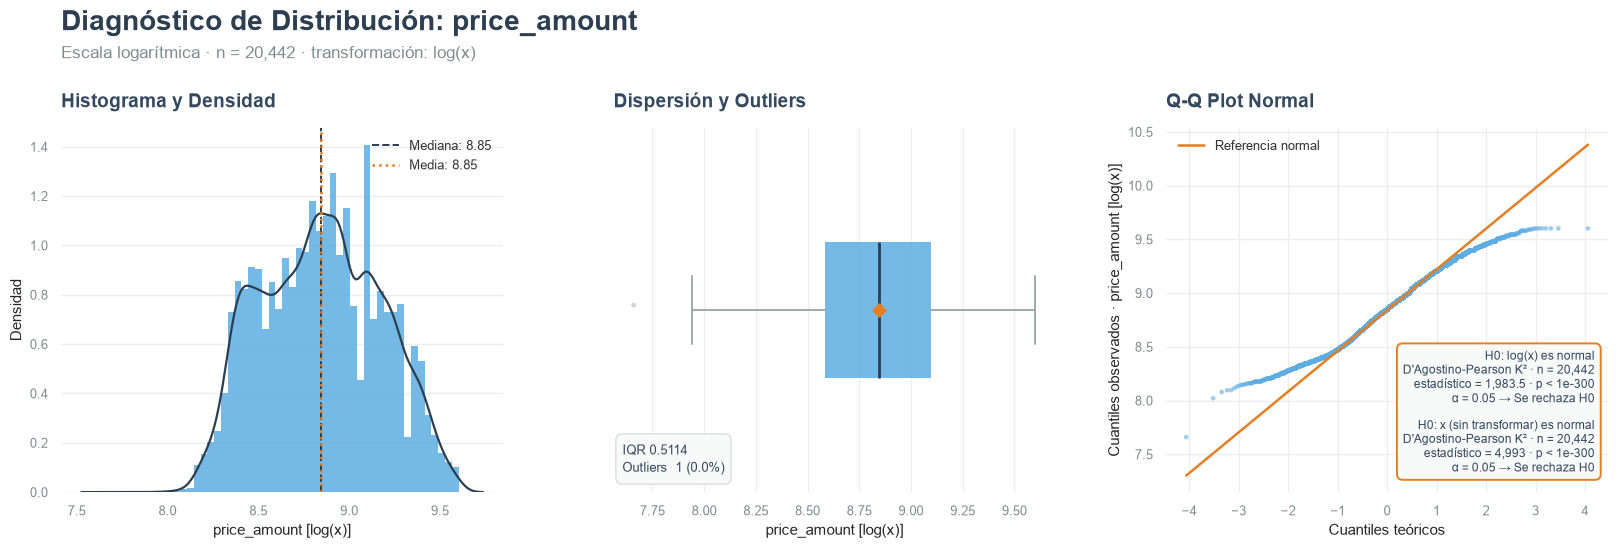

In [80]:
output = normality_report(
    df,
    'price_amount',
    log_transformation=True
    )

In [81]:
# Fuente: Toloza-Delgado et al. (2021), Tabla 2 — Bogotá, vivienda nueva, nov-2019
Q1, Q3 = 214_925_000, 504_250_000
ipc_2020_ago2026 = 1.0161 * 1.0562 * 1.1312 * 1.0928 * 1.0520 * 1.0510 * 1.0535   # ≈ 1.3957

mu_2019 = (np.log(Q1) + np.log(Q3)) / 2 # aproximacion a la media
sigma2_0 = ((np.log(Q3) - np.log(Q1)) / (2 * 0.6745))**2

mu_0 = mu_2019 + np.log(ipc_2020_ago2026)     # 19.9456
k_0  = 10
a_0  = 5                                    # 5
b_0  = (a_0 - 1) * sigma2_0                 # (despejando)

muestra = df_diric["price_amount"].sample(n=300, random_state=42)
y = np.log(muestra)
n, ybar, s2 = len(y), y.mean(), y.var(ddof=1)

# posterior NIG
k_n  = k_0 + n
mu_n = (k_0 * mu_0 + n * ybar) / k_n
a_n  = a_0 + n / 2
b_n  = b_0 + 0.5 * (n - 1) * s2 + (k_0 * n * (ybar - mu_0)**2) / (2 * k_n)

### Especificación del modelo

Datos: $y_i = \ln(\text{precio}_i)$, $i = 1, \dots, n$, con $n = 300$, $\bar{y} = 20{,}3902$, $s^2 = 0{,}5396$ y $(n-1)s^2 = 161{,}3272$.

**Verosimilitud.**

$$y_i \mid \mu, \sigma^2 \overset{iid}{\sim} N(\mu;\ \sigma^2)$$

$$p(\mathbf{y} \mid \mu, \sigma^2) = \prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma^2}}\,e^{-\frac{(y_i-\mu)^2}{2\sigma^2}} = (2\pi\sigma^2)^{-n/2}\exp\left\{-\frac{(n-1)s^2 + n(\bar{y}-\mu)^2}{2\sigma^2}\right\}$$

$$p(\mathbf{y} \mid \mu, \sigma^2) = (2\pi\sigma^2)^{-150}\exp\left\{-\frac{161{,}3272 + 300\,(20{,}3902-\mu)^2}{2\sigma^2}\right\}$$

**Prior.** $(\mu, \sigma^2) \sim \text{NIG}(\mu_0, \kappa_0, a_0, b_0) = \text{NIG}(20{,}0474;\ 10;\ 5;\ 1{,}5985)$, es decir

$$\mu \mid \sigma^2 \sim N\!\left(\mu_0;\ \frac{\sigma^2}{\kappa_0}\right) = N\!\left(20{,}0474;\ \frac{\sigma^2}{10}\right), \qquad \sigma^2 \sim \text{Inv-Gamma}(a_0;\ b_0) = \text{Inv-Gamma}(5;\ 1{,}5985)$$

$$p(\mu, \sigma^2) = \sqrt{\frac{\kappa_0}{2\pi\sigma^2}}\exp\left\{-\frac{\kappa_0(\mu-\mu_0)^2}{2\sigma^2}\right\}\cdot\frac{b_0^{a_0}}{\Gamma(a_0)}(\sigma^2)^{-(a_0+1)}e^{-b_0/\sigma^2}$$

$$p(\mu, \sigma^2) = \sqrt{\frac{10}{2\pi\sigma^2}}\exp\left\{-\frac{10\,(\mu-20{,}0474)^2}{2\sigma^2}\right\}\cdot\frac{1{,}5985^{5}}{\Gamma(5)}(\sigma^2)^{-6}e^{-1{,}5985/\sigma^2}$$

**Posterior.** $(\mu, \sigma^2) \mid \mathbf{y} \sim \text{NIG}(\mu_n, \kappa_n, a_n, b_n)$ con

$$\begin{aligned}
\kappa_n &= \kappa_0 + n = 10 + 300 = 310 \\
\mu_n &= \frac{\kappa_0\mu_0 + n\bar{y}}{\kappa_n} = \frac{10(20{,}0474) + 300(20{,}3902)}{310} = 20{,}3791 \\
a_n &= a_0 + \frac{n}{2} = 5 + \frac{300}{2} = 155 \\
b_n &= b_0 + \tfrac{1}{2}(n-1)s^2 + \frac{\kappa_0\,n(\bar{y}-\mu_0)^2}{2\kappa_n} \\
&= 1{,}5985 + \tfrac{1}{2}(299)(0{,}5396) + \frac{10\cdot300\,(20{,}3902-20{,}0474)^2}{2\cdot310} \\
&= 1{,}5985 + 80{,}6636 + 0{,}5685 \approx 82{,}8306
\end{aligned}$$

$$(\mu, \sigma^2) \mid \mathbf{y} \sim \text{NIG}(20{,}3791;\ 310;\ 155;\ 82{,}8306)$$

$$p(\mu, \sigma^2 \mid \mathbf{y}) = \sqrt{\frac{310}{2\pi\sigma^2}}\exp\left\{-\frac{310\,(\mu-20{,}3791)^2}{2\sigma^2}\right\}\cdot\frac{82{,}8306^{155}}{\Gamma(155)}(\sigma^2)^{-156}e^{-82{,}8306/\sigma^2}$$

Marginales posteriores (las que se grafican abajo):

$$\mu \mid \mathbf{y} \sim t_{2a_n}\!\left(\mu_n;\ \frac{b_n}{a_n\kappa_n}\right) = t_{310}\!\left(20{,}3791;\ 0{,}001724\right), \qquad \sigma^2 \mid \mathbf{y} \sim \text{Inv-Gamma}(155;\ 82{,}8306)$$

donde el segundo parámetro de la $t$ es la escala al cuadrado.

In [82]:
mu_0

np.float64(20.047415928679083)

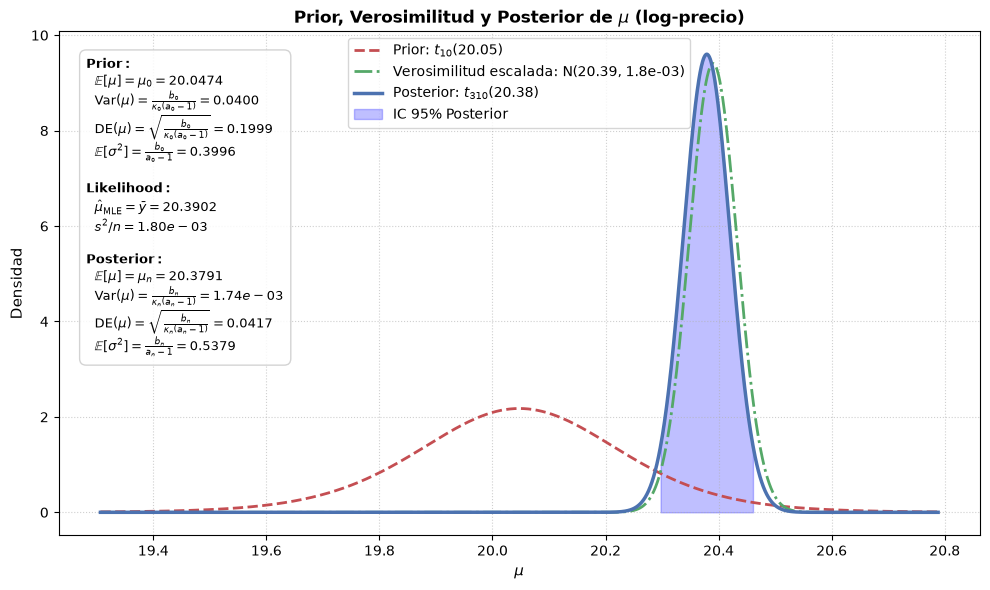

In [83]:
# Marginal de mu bajo NIG: t_{2a}(m, b / (a k)); verosimilitud escalada N(ybar, s2/n)
prior_mu = t(2 * a_0, loc=mu_0, scale=np.sqrt(b_0 / (a_0 * k_0)))
like_mu = norm(ybar, np.sqrt(s2 / n))
post_mu = t(2 * a_n, loc=mu_n, scale=np.sqrt(b_n / (a_n * k_n)))
ci = post_mu.interval(0.95)

x = np.linspace(*prior_mu.ppf([0.001, 0.999]), 2000)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, prior_mu.pdf(x), 'r--', lw=2, label=f'Prior: $t_{{{2 * a_0}}}$({mu_0:.2f})')
ax.plot(x, like_mu.pdf(x), 'g-.', lw=2, label=f'Verosimilitud escalada: N({ybar:.2f}, {s2 / n:.1e})')
ax.plot(x, post_mu.pdf(x), 'b-', lw=2.5, label=f'Posterior: $t_{{{2 * a_n:.0f}}}$({mu_n:.2f})')

x_fill = np.linspace(*ci, 200)
ax.fill_between(x_fill, post_mu.pdf(x_fill), color='blue', alpha=0.25, label='IC 95% Posterior')

# Momentos con su fórmula (como en las gráficas anteriores)
stats_text = (
    r"$\mathbf{Prior:}$" "\n"
    rf"  $\mathbb{{E}}[\mu] = \mu_0 = {mu_0:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\mu) = \frac{{b_0}}{{\kappa_0(a_0-1)}} = {b_0 / (k_0 * (a_0 - 1)):.4f}$" "\n"
    rf"  $\mathrm{{DE}}(\mu) = \sqrt{{\frac{{b_0}}{{\kappa_0(a_0-1)}}}} = {np.sqrt(b_0 / (k_0 * (a_0 - 1))):.4f}$" "\n"
    rf"  $\mathbb{{E}}[\sigma^2] = \frac{{b_0}}{{a_0-1}} = {b_0 / (a_0 - 1):.4f}$" "\n\n"
    r"$\mathbf{Likelihood:}$" "\n"
    rf"  $\hat{{\mu}}_{{\mathrm{{MLE}}}} = \bar{{y}} = {ybar:.4f}$" "\n"
    rf"  $s^2 / n = {s2 / n:.2e}$" "\n\n"
    r"$\mathbf{Posterior:}$" "\n"
    rf"  $\mathbb{{E}}[\mu] = \mu_n = {mu_n:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\mu) = \frac{{b_n}}{{\kappa_n(a_n-1)}} = {b_n / (k_n * (a_n - 1)):.2e}$" "\n"
    rf"  $\mathrm{{DE}}(\mu) = \sqrt{{\frac{{b_n}}{{\kappa_n(a_n-1)}}}} = {np.sqrt(b_n / (k_n * (a_n - 1))):.4f}$" "\n"
    rf"  $\mathbb{{E}}[\sigma^2] = \frac{{b_n}}{{a_n-1}} = {b_n / (a_n - 1):.4f}$"
)
ax.text(0.03, 0.95, stats_text, transform=ax.transAxes, fontsize=9.5, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.85))

ax.set_title(r'Prior, Verosimilitud y Posterior de $\mu$ (log-precio)', fontsize=12, fontweight='bold')
ax.set_xlabel(r'$\mu$', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.legend(loc='upper center', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

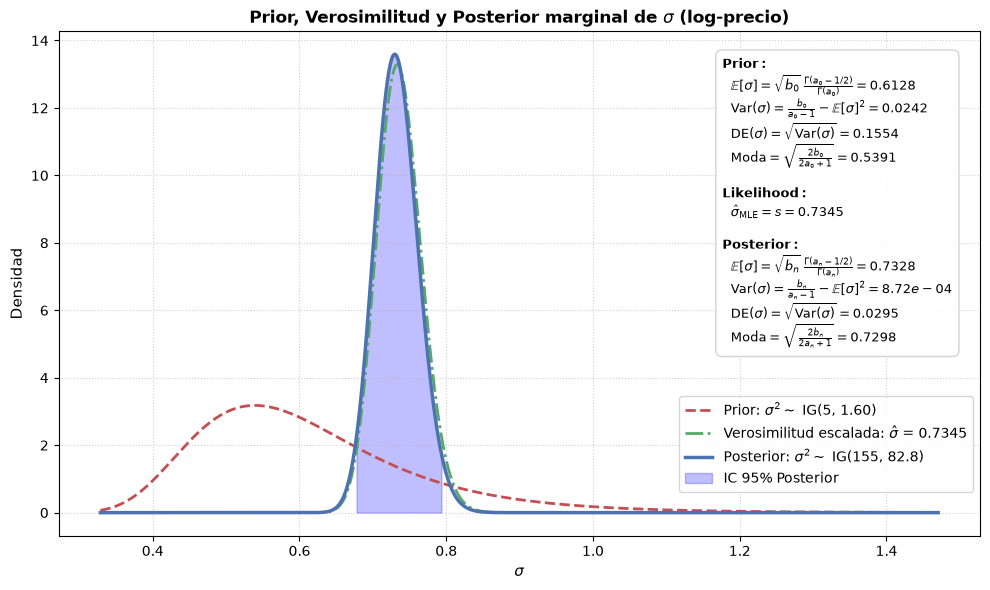

In [84]:
# Marginal de sigma bajo NIG: sigma^2 ~ InvGamma(a, b)  =>  sigma ~ GenGamma(a, c=-2, escala=sqrt(b))
# Verosimilitud escalada en sigma: prop. a sigma^-n exp(-(n-1)s2 / (2 sigma^2)), misma familia
prior_sigma = gengamma(a_0, -2, scale=np.sqrt(b_0))
like_sigma = gengamma((n - 1) / 2, -2, scale=np.sqrt((n - 1) * s2 / 2))
post_sigma = gengamma(a_n, -2, scale=np.sqrt(b_n))
ci = post_sigma.interval(0.95)

# Momentos de sigma (gammaln evita el desbordamiento de Gamma(a_n) con a_n ~ 10^4)
def momentos_sigma(a, b):
    e = np.sqrt(b) * np.exp(special.gammaln(a - 0.5) - special.gammaln(a))
    return e, b / (a - 1) - e**2, np.sqrt(2 * b / (2 * a + 1))

e_pri, var_pri, moda_pri = momentos_sigma(a_0, b_0)
e_pos, var_pos, moda_pos = momentos_sigma(a_n, b_n)

x = np.linspace(*prior_sigma.ppf([0.001, 0.999]), 2000)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, prior_sigma.pdf(x), 'r--', lw=2, label=f'Prior: $\\sigma^2 \\sim$ IG({a_0}, {b_0:.2f})')
ax.plot(x, like_sigma.pdf(x), 'g-.', lw=2, label=f'Verosimilitud escalada: $\\hat{{\\sigma}}$ = {np.sqrt(s2):.4f}')
ax.plot(x, post_sigma.pdf(x), 'b-', lw=2.5, label=f'Posterior: $\\sigma^2 \\sim$ IG({a_n:.0f}, {b_n:.1f})')

x_fill = np.linspace(*ci, 200)
ax.fill_between(x_fill, post_sigma.pdf(x_fill), color='blue', alpha=0.25, label='IC 95% Posterior')

# Momentos con su fórmula (como en las gráficas anteriores)
stats_text = (
    r"$\mathbf{Prior:}$" "\n"
    rf"  $\mathbb{{E}}[\sigma] = \sqrt{{b_0}}\,\frac{{\Gamma(a_0-1/2)}}{{\Gamma(a_0)}} = {e_pri:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\sigma) = \frac{{b_0}}{{a_0-1}} - \mathbb{{E}}[\sigma]^2 = {var_pri:.4f}$" "\n"
    rf"  $\mathrm{{DE}}(\sigma) = \sqrt{{\mathrm{{Var}}(\sigma)}} = {np.sqrt(var_pri):.4f}$" "\n"
    rf"  $\mathrm{{Moda}} = \sqrt{{\frac{{2b_0}}{{2a_0+1}}}} = {moda_pri:.4f}$" "\n\n"
    r"$\mathbf{Likelihood:}$" "\n"
    rf"  $\hat{{\sigma}}_{{\mathrm{{MLE}}}} = s = {np.sqrt(s2):.4f}$" "\n\n"
    r"$\mathbf{Posterior:}$" "\n"
    rf"  $\mathbb{{E}}[\sigma] = \sqrt{{b_n}}\,\frac{{\Gamma(a_n-1/2)}}{{\Gamma(a_n)}} = {e_pos:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\sigma) = \frac{{b_n}}{{a_n-1}} - \mathbb{{E}}[\sigma]^2 = {var_pos:.2e}$" "\n"
    rf"  $\mathrm{{DE}}(\sigma) = \sqrt{{\mathrm{{Var}}(\sigma)}} = {np.sqrt(var_pos):.4f}$" "\n"
    rf"  $\mathrm{{Moda}} = \sqrt{{\frac{{2b_n}}{{2a_n+1}}}} = {moda_pos:.4f}$"
)
ax.text(0.97, 0.95, stats_text, transform=ax.transAxes, fontsize=9.5, va='top', ha='right', multialignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.85))

ax.set_title(r'Prior, Verosimilitud y Posterior marginal de $\sigma$ (log-precio)', fontsize=12, fontweight='bold')
ax.set_xlabel(r'$\sigma$', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.legend(loc='upper right', bbox_to_anchor=(1, 0.29), frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Intervalos

In [85]:
dists_post = {
    'I.C al 95% para mu':post_mu,
    'I.C al 95% para sigma':post_sigma
    }

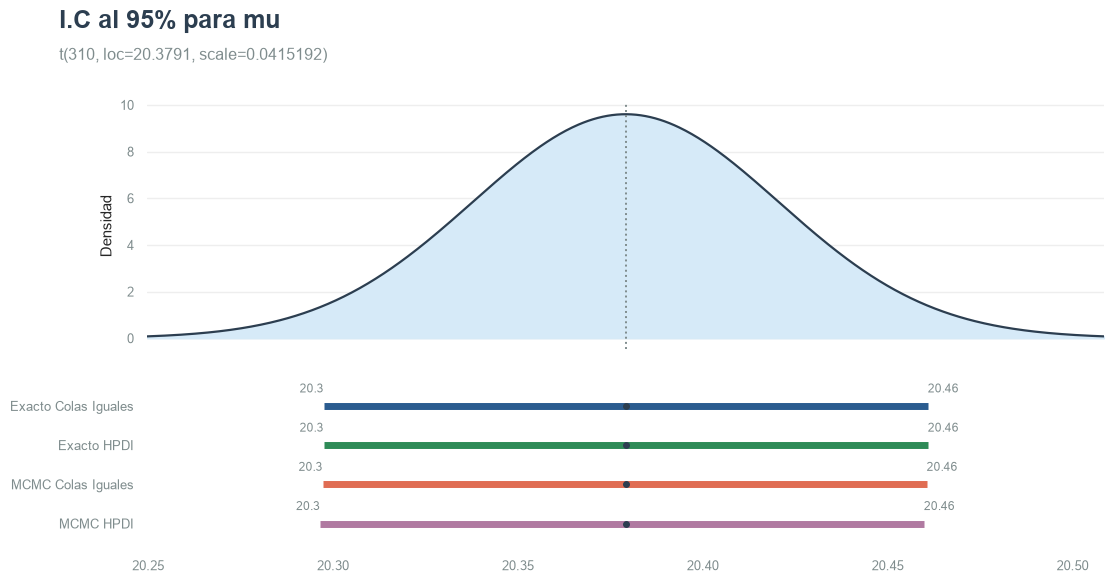

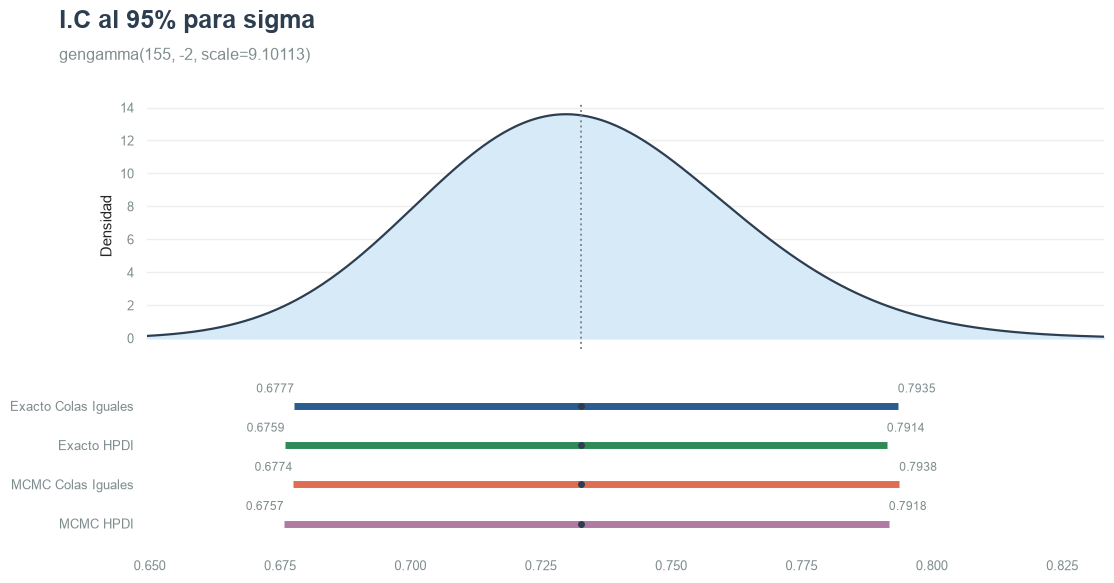

In [86]:
ic = []
for nombre, dist in dists_post.items():
    ic.append(credible_intervals(dist, plot=True, title=nombre))

In [87]:
for i in ic:
    i['limite_inferior'] = np.exp(i['limite_inferior'])
    i['limite_superior'] = np.exp(i['limite_superior'])
    display(i)

,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,6.532317e+08,7.691777e+08,0.163390
1,Exacto,HPDI,0.95,6.532317e+08,7.691777e+08,0.163390
2,MCMC,Colas Iguales,0.95,6.530524e+08,7.689320e+08,0.163345
3,MCMC,HPDI,0.95,6.526059e+08,7.683649e+08,0.163291


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,1.969401,2.211073,0.115749
1,Exacto,HPDI,0.95,1.965781,2.206437,0.115490
2,MCMC,Colas Iguales,0.95,1.968787,2.211688,0.116338
3,MCMC,HPDI,0.95,1.965478,2.207289,0.116030


### Predictivas

In [88]:
def nig_predictive_params(mu, k, a, b):
    df_t = 2 * a
    loc_t = mu
    scale_sq = (b * (k + 1)) / (a * k)
    scale_t = np.sqrt(scale_sq)

    return {
        "df": df_t,
        "loc": loc_t,
        "scale": scale_t,
        "var_predictiva": scale_sq
    }

#### Prior

In [89]:
pred_prior = nig_predictive_params(mu_0, k_0, a_0, b_0)
pred_prior

{'df': 10,
 'loc': np.float64(20.047415928679083),
 'scale': np.float64(0.5930180937432362),
 'var_predictiva': np.float64(0.3516704595068617)}

In [90]:
media_pred_prior = mu_0
print(f"E(ỹ) = μ₀ = {pred_prior['loc']:.4f}  (log-precio)")
print(f"Mediana de la predictiva a priori: ${np.exp(pred_prior['loc']) / 1e6:,.1f} millones COP")

E(ỹ) = μ₀ = 20.0474  (log-precio)
Mediana de la predictiva a priori: $508.7 millones COP


#### Posterior

In [91]:
pred_post = nig_predictive_params(mu_n, k_n, a_n, b_n)
pred_post

{'df': 310.0,
 'loc': np.float64(20.379137466984883),
 'scale': np.float64(0.7321987689421758),
 'var_predictiva': np.float64(0.5361150372404379)}

In [92]:
media_pred_post = mu_n
print(f"E(ỹ) = μ_n = {pred_post['loc']:.4f}  (log-precio)")
print(f"Mediana de la predictiva a posteriori: ${np.exp(pred_post['loc']) / 1e6:,.1f} millones COP")

E(ỹ) = μ_n = 20.3791  (log-precio)
Mediana de la predictiva a posteriori: $708.8 millones COP


### Interpretación General

Se aprecia como se reduce la incertidumbre sobre los parametros $\mu$ y $\sigma^2$, sin embargo estos dos amuentaron en los datos observados respecto a los apriori, lo cual sugiere un aumento en los precios de la vivienda en Bogotá, si bien el aumento de precio se ve poco drastico bajo la transformación log, esta se ve de manera mas fuerte con las medianas predictivas en las unidades originales, pues el precio esperado para un nuevo inmueble pasa de $508.7 millones a $708.8 millones.

De ese aumento en el valor medio del precio tambien se deriva un aumento en la varianza de estos mismos (aumque la varianza de la inferencia sobre estos dos estimadores si que se reduce).

## Para `area_built_m2_log`

(a pesar de no ser normal se usará el modelo normal gamma al ser la herramienta dispotible que mejor modela esos datos)

Los hiperparámetros se calibran con Toloza‑Delgado, Melo‑Martínez y Azcárate‑Romero (2021), quienes reportan para 708 proyectos de vivienda en venta en Bogotá (Coordenada Urbana, noviembre de 2019) un área construida con primer y tercer cuartil de 47 m² y 81 m².

Dado el sesgo a la derecha del área (máx. 403 m²), el modelo se hace sobre el logaritmo del área. Bajo log‑normalidad, los cuartiles implican una log‑mediana de 4,12 y una desviación estándar logarítmica de 0,403. A diferencia del precio, el área no requiere ajuste temporal, por lo que μ₀ = 4,12 (mediana ≈ 61,7 m²).

Se fija κ₀ = 10. Para la varianza se usa a₀ = 5 y b₀ = (a₀ − 1)·σ̂² = 0,65, de modo que E[σ²] coincide con la varianza logarítmica de la fuente (σ̂² ≈ 0,163).

| Parámetro | Valor | Cálculo | Justificación | Fuente |
|---|---|---|---|---|
| $Q_1$, $Q_3$ | 47 m² ; 81 m² | Tomados de la Tabla 2 (m²) | Cuartiles del área de 708 proyectos de vivienda en Bogotá (nov‑2019). Se usan cuartiles y no media/DE porque son invariantes a la transformación logarítmica y robustos a la cola derecha (máx. 403 m²) | Toloza‑Delgado et al. (2021), Tabla 2 |
| $\ln Q_1$, $\ln Q_3$ | $3{,}8501$ ; $4{,}3944$ | $\ln(47)$ ; $\ln(81)$ | Por invarianza de los cuantiles ante transformaciones monótonas, son exactamente los cuartiles del log‑área | — |
| $\hat\mu$ | $4{,}1223$ | $(\ln Q_1 + \ln Q_3)/2$ | Bajo normalidad aproximada de area_built_m2_log, la log‑mediana es el punto medio de los cuartiles. Equivale a una mediana de 61,7 m² | — |
| $\hat\sigma^2$ | $0{,}1628$ | $\left[(\ln Q_3 - \ln Q_1)/(2 \times 0{,}6745)\right]^2 = 0{,}4035^2$ | El rango intercuartílico de una Normal mide $2 \times 0{,}6745\,\sigma$ | — |
| Ajuste temporal | No aplica | — | El área se mide en unidades físicas (m²), que no se deprecian ni se inflan con el tiempo, a diferencia del precio | — |
| $\mu_0$ | $4{,}1223$ | $\mu_0 = \hat\mu$ | Al no requerir ajuste, la log‑mediana de la fuente se usa directamente. Mediana a priori 61,7 m² | — |

$$ b_0 = (a_0 - 1)\,\hat\sigma^2 = 4 \times 0{,}1628 = 0{,}6512$$


fuente: https://doi.org/10.17230/ingciencia.17.34.2

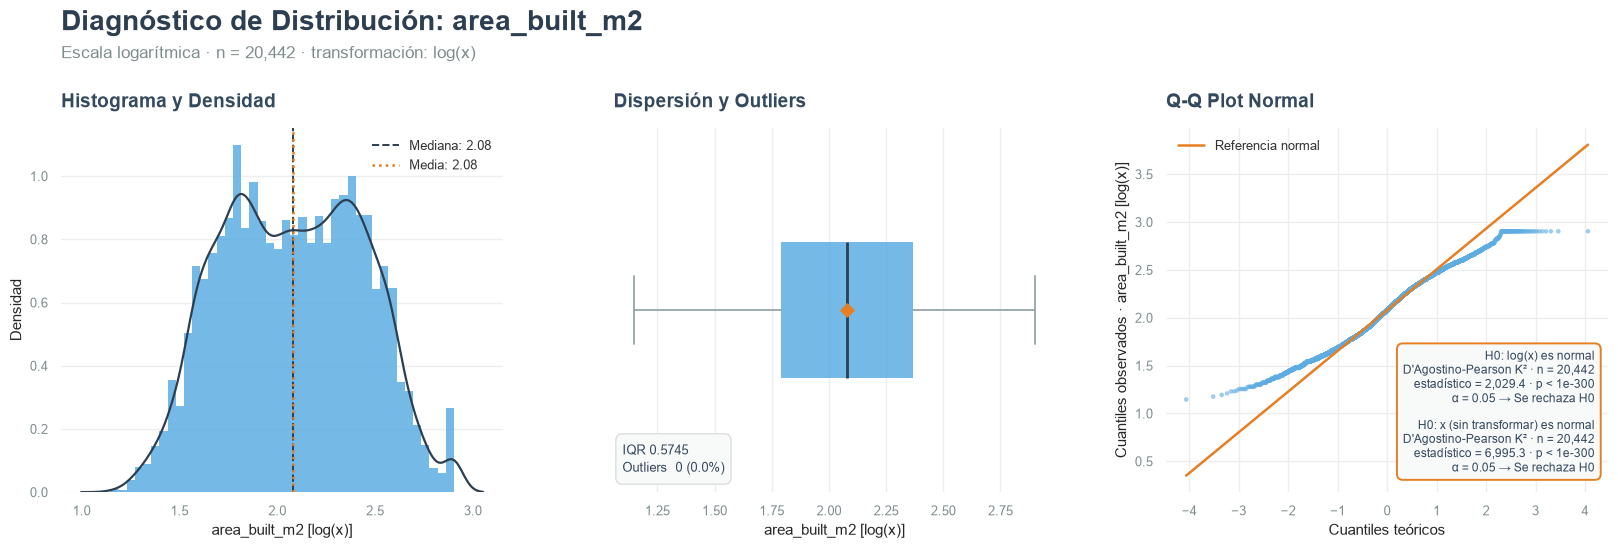

In [93]:
output = normality_report(
    df,
    'area_built_m2',
    log_transformation=True
    )

In [94]:
# Fuente: Toloza-Delgado et al. (2021), Tabla 2 — Bogotá, vivienda nueva, nov-2019
Q1, Q3 = 47, 81
mu_2019 = (np.log(Q1) + np.log(Q3)) / 2 # aproximacion a la media
sigma2_0 = ((np.log(Q3) - np.log(Q1)) / (2 * 0.6745))**2

mu_0 = mu_2019
k_0  = 10
a_0  = 5                                    # 5
b_0  = (a_0 - 1) * sigma2_0                 # (despejando)

muestra = df["area_built_m2"].sample(n=300, random_state=42)
y = np.log(muestra)
n, ybar, s2 = len(y), y.mean(), y.var(ddof=1)

# posterior NIG
k_n  = k_0 + n
mu_n = (k_0 * mu_0 + n * ybar) / k_n
a_n  = a_0 + n / 2
b_n  = b_0 + 0.5 * (n - 1) * s2 + (k_0 * n * (ybar - mu_0)**2) / (2 * k_n)

### Especificación del modelo

Datos: $y_i = \ln(\text{área}_i)$, $i = 1, \dots, n$, con $n = 300$, $\bar{y} = 4{,}7841$, $s^2 = 0{,}6852$ y $(n-1)s^2 = 204{,}8795$.

**Verosimilitud.**

$$y_i \mid \mu, \sigma^2 \overset{iid}{\sim} N(\mu;\ \sigma^2)$$

$$p(\mathbf{y} \mid \mu, \sigma^2) = \prod_{i=1}^{n}\frac{1}{\sqrt{2\pi\sigma^2}}\,e^{-\frac{(y_i-\mu)^2}{2\sigma^2}} = (2\pi\sigma^2)^{-n/2}\exp\left\{-\frac{(n-1)s^2 + n(\bar{y}-\mu)^2}{2\sigma^2}\right\}$$

$$p(\mathbf{y} \mid \mu, \sigma^2) = (2\pi\sigma^2)^{-150}\exp\left\{-\frac{204{,}8795 + 300\,(4{,}7841-\mu)^2}{2\sigma^2}\right\}$$

**Prior.** $(\mu, \sigma^2) \sim \text{NIG}(\mu_0, \kappa_0, a_0, b_0) = \text{NIG}(4{,}1223;\ 10;\ 5;\ 0{,}6512)$, es decir

$$\mu \mid \sigma^2 \sim N\!\left(\mu_0;\ \frac{\sigma^2}{\kappa_0}\right) = N\!\left(4{,}1223;\ \frac{\sigma^2}{10}\right), \qquad \sigma^2 \sim \text{Inv-Gamma}(a_0;\ b_0) = \text{Inv-Gamma}(5;\ 0{,}6512)$$

$$p(\mu, \sigma^2) = \sqrt{\frac{\kappa_0}{2\pi\sigma^2}}\exp\left\{-\frac{\kappa_0(\mu-\mu_0)^2}{2\sigma^2}\right\}\cdot\frac{b_0^{a_0}}{\Gamma(a_0)}(\sigma^2)^{-(a_0+1)}e^{-b_0/\sigma^2}$$

$$p(\mu, \sigma^2) = \sqrt{\frac{10}{2\pi\sigma^2}}\exp\left\{-\frac{10\,(\mu-4{,}1223)^2}{2\sigma^2}\right\}\cdot\frac{0{,}6512^{5}}{\Gamma(5)}(\sigma^2)^{-6}e^{-0{,}6512/\sigma^2}$$

**Posterior.** $(\mu, \sigma^2) \mid \mathbf{y} \sim \text{NIG}(\mu_n, \kappa_n, a_n, b_n)$ con

$$\begin{aligned}
\kappa_n &= \kappa_0 + n = 10 + 300 = 310 \\
\mu_n &= \frac{\kappa_0\mu_0 + n\bar{y}}{\kappa_n} = \frac{10(4{,}1223) + 300(4{,}7841)}{310} = 4{,}7628 \\
a_n &= a_0 + \frac{n}{2} = 5 + \frac{300}{2} = 155 \\
b_n &= b_0 + \tfrac{1}{2}(n-1)s^2 + \frac{\kappa_0\,n(\bar{y}-\mu_0)^2}{2\kappa_n} \\
&= 0{,}6512 + \tfrac{1}{2}(299)(0{,}6852) + \frac{10\cdot300\,(4{,}7841-4{,}1223)^2}{2\cdot310} \\
&= 0{,}6512 + 102{,}4397 + 2{,}1194 \approx 105{,}2104
\end{aligned}$$

$$(\mu, \sigma^2) \mid \mathbf{y} \sim \text{NIG}(4{,}7628;\ 310;\ 155;\ 105{,}2104)$$

$$p(\mu, \sigma^2 \mid \mathbf{y}) = \sqrt{\frac{310}{2\pi\sigma^2}}\exp\left\{-\frac{310\,(\mu-4{,}7628)^2}{2\sigma^2}\right\}\cdot\frac{105{,}2104^{155}}{\Gamma(155)}(\sigma^2)^{-156}e^{-105{,}2104/\sigma^2}$$

Marginales posteriores (las que se grafican abajo):

$$\mu \mid \mathbf{y} \sim t_{2a_n}\!\left(\mu_n;\ \frac{b_n}{a_n\kappa_n}\right) = t_{310}\!\left(4{,}7628;\ 0{,}00219\right), \qquad \sigma^2 \mid \mathbf{y} \sim \text{Inv-Gamma}(155;\ 105{,}2104)$$

donde el segundo parámetro de la $t$ es la escala al cuadrado.

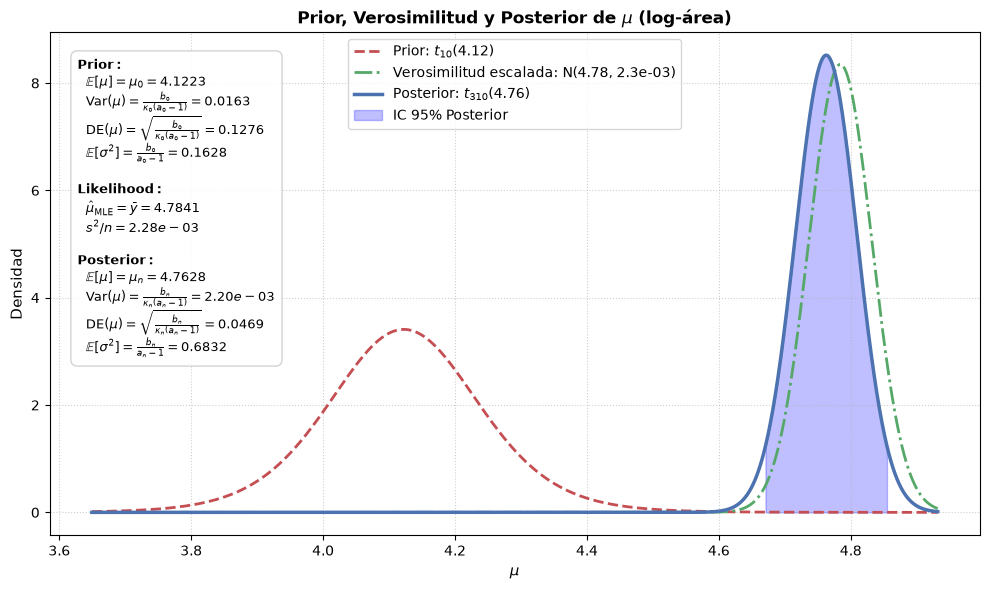

In [95]:
# Marginal de mu bajo NIG: t_{2a}(m, b / (a k)); verosimilitud escalada N(ybar, s2/n)
prior_mu = t(2 * a_0, loc=mu_0, scale=np.sqrt(b_0 / (a_0 * k_0)))
like_mu = norm(ybar, np.sqrt(s2 / n))
post_mu = t(2 * a_n, loc=mu_n, scale=np.sqrt(b_n / (a_n * k_n)))
ci = post_mu.interval(0.95)

dists = (prior_mu, like_mu, post_mu)
x = np.linspace(min(d.ppf(0.001) for d in dists), max(d.ppf(0.999) for d in dists), 2000)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, prior_mu.pdf(x), 'r--', lw=2, label=f'Prior: $t_{{{2 * a_0}}}$({mu_0:.2f})')
ax.plot(x, like_mu.pdf(x), 'g-.', lw=2, label=f'Verosimilitud escalada: N({ybar:.2f}, {s2 / n:.1e})')
ax.plot(x, post_mu.pdf(x), 'b-', lw=2.5, label=f'Posterior: $t_{{{2 * a_n:.0f}}}$({mu_n:.2f})')

x_fill = np.linspace(*ci, 200)
ax.fill_between(x_fill, post_mu.pdf(x_fill), color='blue', alpha=0.25, label='IC 95% Posterior')

# Momentos con su fórmula (como en las gráficas anteriores)
stats_text = (
    r"$\mathbf{Prior:}$" "\n"
    rf"  $\mathbb{{E}}[\mu] = \mu_0 = {mu_0:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\mu) = \frac{{b_0}}{{\kappa_0(a_0-1)}} = {b_0 / (k_0 * (a_0 - 1)):.4f}$" "\n"
    rf"  $\mathrm{{DE}}(\mu) = \sqrt{{\frac{{b_0}}{{\kappa_0(a_0-1)}}}} = {np.sqrt(b_0 / (k_0 * (a_0 - 1))):.4f}$" "\n"
    rf"  $\mathbb{{E}}[\sigma^2] = \frac{{b_0}}{{a_0-1}} = {b_0 / (a_0 - 1):.4f}$" "\n\n"
    r"$\mathbf{Likelihood:}$" "\n"
    rf"  $\hat{{\mu}}_{{\mathrm{{MLE}}}} = \bar{{y}} = {ybar:.4f}$" "\n"
    rf"  $s^2 / n = {s2 / n:.2e}$" "\n\n"
    r"$\mathbf{Posterior:}$" "\n"
    rf"  $\mathbb{{E}}[\mu] = \mu_n = {mu_n:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\mu) = \frac{{b_n}}{{\kappa_n(a_n-1)}} = {b_n / (k_n * (a_n - 1)):.2e}$" "\n"
    rf"  $\mathrm{{DE}}(\mu) = \sqrt{{\frac{{b_n}}{{\kappa_n(a_n-1)}}}} = {np.sqrt(b_n / (k_n * (a_n - 1))):.4f}$" "\n"
    rf"  $\mathbb{{E}}[\sigma^2] = \frac{{b_n}}{{a_n-1}} = {b_n / (a_n - 1):.4f}$"
)
ax.text(0.03, 0.95, stats_text, transform=ax.transAxes, fontsize=9.5, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.85))

ax.set_title(r'Prior, Verosimilitud y Posterior de $\mu$ (log-área)', fontsize=12, fontweight='bold')
ax.set_xlabel(r'$\mu$', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.legend(loc='upper center', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

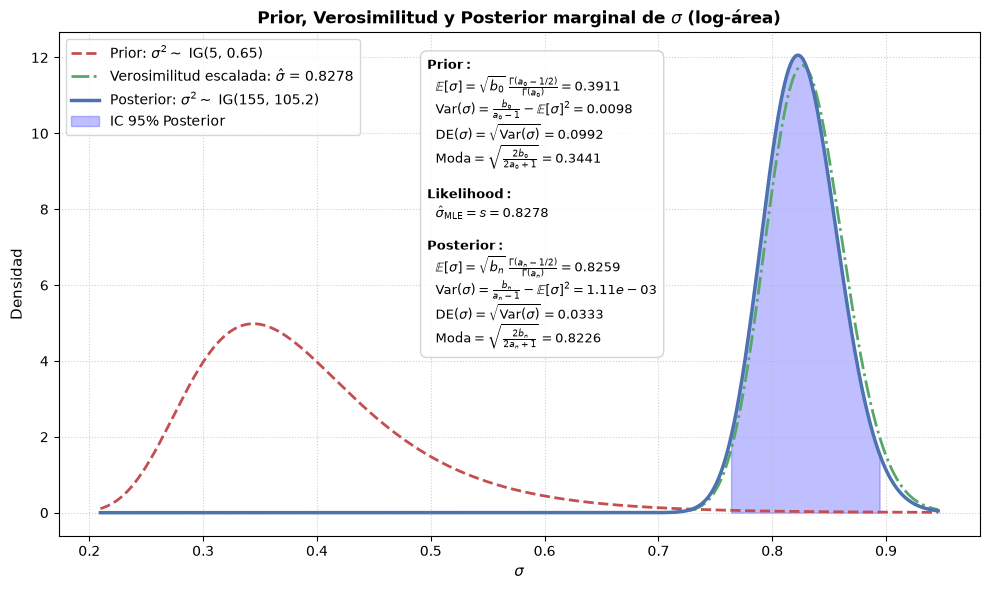

In [96]:
# Marginal de sigma bajo NIG: sigma^2 ~ InvGamma(a, b)  =>  sigma ~ GenGamma(a, c=-2, escala=sqrt(b))
# Verosimilitud escalada en sigma: prop. a sigma^-n exp(-(n-1)s2 / (2 sigma^2)), misma familia
prior_sigma = gengamma(a_0, -2, scale=np.sqrt(b_0))
like_sigma = gengamma((n - 1) / 2, -2, scale=np.sqrt((n - 1) * s2 / 2))
post_sigma = gengamma(a_n, -2, scale=np.sqrt(b_n))
ci = post_sigma.interval(0.95)

# Momentos de sigma (gammaln evita el desbordamiento de Gamma(a_n) con a_n grande)
def momentos_sigma(a, b):
    e = np.sqrt(b) * np.exp(special.gammaln(a - 0.5) - special.gammaln(a))
    return e, b / (a - 1) - e**2, np.sqrt(2 * b / (2 * a + 1))

e_pri, var_pri, moda_pri = momentos_sigma(a_0, b_0)
e_pos, var_pos, moda_pos = momentos_sigma(a_n, b_n)

dists = (prior_sigma, like_sigma, post_sigma)
x = np.linspace(min(d.ppf(0.001) for d in dists), max(d.ppf(0.999) for d in dists), 2000)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, prior_sigma.pdf(x), 'r--', lw=2, label=f'Prior: $\\sigma^2 \\sim$ IG({a_0}, {b_0:.2f})')
ax.plot(x, like_sigma.pdf(x), 'g-.', lw=2, label=f'Verosimilitud escalada: $\\hat{{\\sigma}}$ = {np.sqrt(s2):.4f}')
ax.plot(x, post_sigma.pdf(x), 'b-', lw=2.5, label=f'Posterior: $\\sigma^2 \\sim$ IG({a_n:.0f}, {b_n:.1f})')

x_fill = np.linspace(*ci, 200)
ax.fill_between(x_fill, post_sigma.pdf(x_fill), color='blue', alpha=0.25, label='IC 95% Posterior')

# Momentos con su fórmula (como en las gráficas anteriores)
stats_text = (
    r"$\mathbf{Prior:}$" "\n"
    rf"  $\mathbb{{E}}[\sigma] = \sqrt{{b_0}}\,\frac{{\Gamma(a_0-1/2)}}{{\Gamma(a_0)}} = {e_pri:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\sigma) = \frac{{b_0}}{{a_0-1}} - \mathbb{{E}}[\sigma]^2 = {var_pri:.4f}$" "\n"
    rf"  $\mathrm{{DE}}(\sigma) = \sqrt{{\mathrm{{Var}}(\sigma)}} = {np.sqrt(var_pri):.4f}$" "\n"
    rf"  $\mathrm{{Moda}} = \sqrt{{\frac{{2b_0}}{{2a_0+1}}}} = {moda_pri:.4f}$" "\n\n"
    r"$\mathbf{Likelihood:}$" "\n"
    rf"  $\hat{{\sigma}}_{{\mathrm{{MLE}}}} = s = {np.sqrt(s2):.4f}$" "\n\n"
    r"$\mathbf{Posterior:}$" "\n"
    rf"  $\mathbb{{E}}[\sigma] = \sqrt{{b_n}}\,\frac{{\Gamma(a_n-1/2)}}{{\Gamma(a_n)}} = {e_pos:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(\sigma) = \frac{{b_n}}{{a_n-1}} - \mathbb{{E}}[\sigma]^2 = {var_pos:.2e}$" "\n"
    rf"  $\mathrm{{DE}}(\sigma) = \sqrt{{\mathrm{{Var}}(\sigma)}} = {np.sqrt(var_pos):.4f}$" "\n"
    rf"  $\mathrm{{Moda}} = \sqrt{{\frac{{2b_n}}{{2a_n+1}}}} = {moda_pos:.4f}$"
)
ax.text(0.40, 0.95, stats_text, transform=ax.transAxes, fontsize=9.5, va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#cccccc', alpha=0.85))

ax.set_title(r'Prior, Verosimilitud y Posterior marginal de $\sigma$ (log-área)', fontsize=12, fontweight='bold')
ax.set_xlabel(r'$\sigma$', fontsize=11)
ax.set_ylabel('Densidad', fontsize=11)
ax.legend(loc='upper left', frameon=True)
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Intervalos

In [97]:
dists_post = {
    'I.C al 95% para mu':post_mu,
    'I.C al 95% para sigma':post_sigma
    }

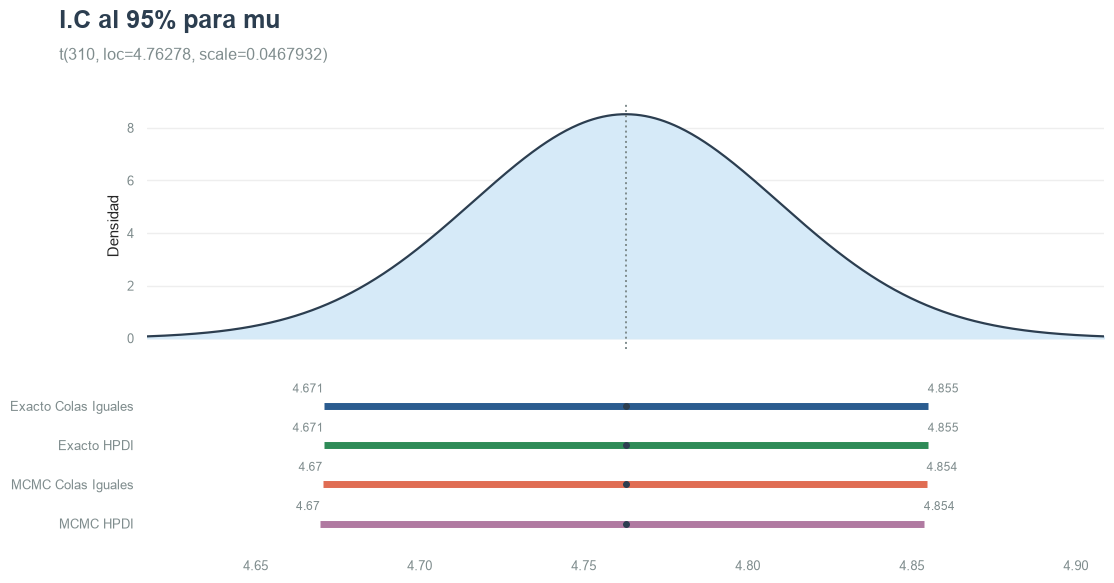

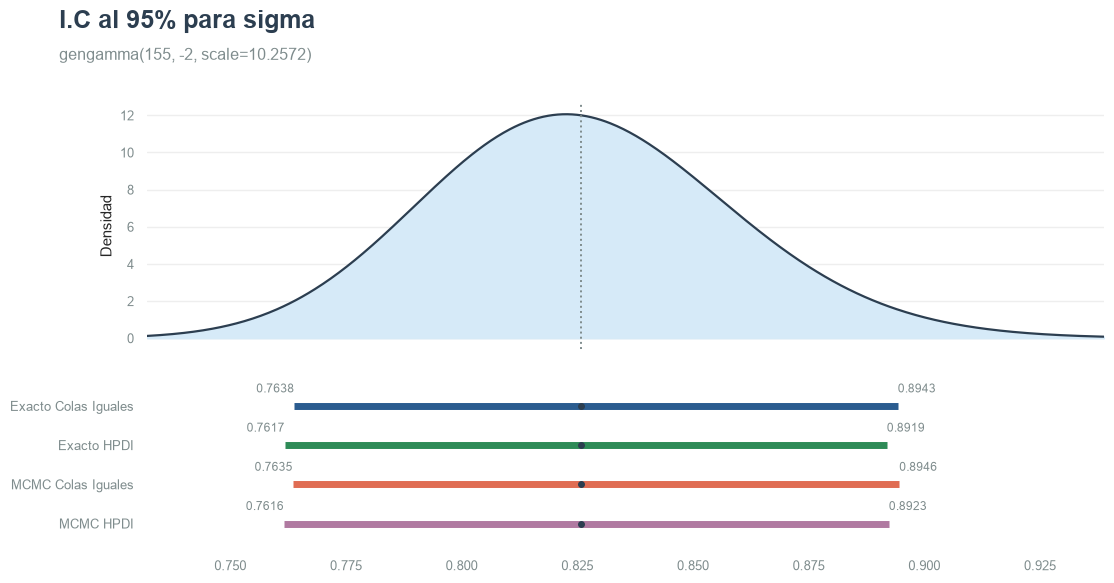

In [98]:
ic = []
for nombre, dist in dists_post.items():
    ic.append(credible_intervals(dist, plot=True, title=nombre))

In [99]:
for i in ic:
    i['limite_inferior'] = np.exp(i['limite_inferior'])
    i['limite_superior'] = np.exp(i['limite_superior'])
    display(i)

,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,106.772787,128.361169,0.184145
1,Exacto,HPDI,0.95,106.772787,128.361169,0.184145
2,MCMC,Colas Iguales,0.95,106.739763,128.314977,0.184094
3,MCMC,HPDI,0.95,106.657522,128.208323,0.184033


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,2.146457,2.445550,0.130452
1,Exacto,HPDI,0.95,2.142010,2.439772,0.130160
2,MCMC,Colas Iguales,0.95,2.145702,2.446316,0.131116
3,MCMC,HPDI,0.95,2.141638,2.440833,0.130769


### Predictivas

#### Prior

In [100]:
pred_prior = nig_predictive_params(mu_0, k_0, a_0, b_0)
pred_prior

{'df': 10,
 'loc': np.float64(4.122298378191249),
 'scale': np.float64(0.3785026808170671),
 'var_predictiva': np.float64(0.14326427938570657)}

In [101]:
pdf_pred_prior = t.pdf(
    x,
    df=pred_prior["df"],
    loc=pred_prior["loc"],
    scale=pred_prior["scale"]
    )
media_pred_prior = mu_0
print(f"E(ỹ) = μ₀ = {pred_prior['loc']:.4f}  (log-área; ν = {pred_prior['df']:.0f} > 1)")
# E[exp(ỹ)] no existe bajo una t (colas pesadas); por eso se reporta la mediana exp(μ)
print(f"Mediana de la predictiva a priori: {np.exp(pred_prior['loc']):,.1f} m²")

E(ỹ) = μ₀ = 4.1223  (log-área; ν = 10 > 1)
Mediana de la predictiva a priori: 61.7 m²


#### Posterior

In [102]:
pred_post = nig_predictive_params(mu_n, k_n, a_n, b_n)
pred_post

{'df': 310.0,
 'loc': np.float64(4.762775510712279),
 'scale': np.float64(0.8252067672902164),
 'var_predictiva': np.float64(0.6809662087815693)}

In [103]:
pdf_pred_post = t.pdf(
    x,
    df=pred_post["df"],
    loc=pred_post["loc"],
    scale=pred_post["scale"]
    )
media_pred_post = mu_n
print(f"E(ỹ) = μ_n = {pred_post['loc']:.4f}  (log-área; ν = {pred_post['df']:.0f} > 1)")
print(f"Mediana de la predictiva a posteriori: {np.exp(pred_post['loc']):,.1f} m²")

E(ỹ) = μ_n = 4.7628  (log-área; ν = 310 > 1)
Mediana de la predictiva a posteriori: 117.1 m²


### Interpretación General

En este caso se aprecia una fuerte discrepancia entre lo observado y lo que se asumia a posteriori, de esta manera viendo un fuerte crecimiento en el valor esperado del metraje cuadrado medio esperado, esto mas que deberse a un cambio de tendencia en el mercado es plausible que se deba a un sesgo de la muestra a viviendas de mayor tamaño, esto pues se detecto dicho sesgo en los datos recolectados (esto se ve mas claramente en las medianas posteriores).

No obstante esto se utiliza como evidencia de que la muestra tiene un sesgo que si bien no se menciono a lo largo de este documento es consistente y es que hay una mayoria de viviendas de mayor valor o tamaño (ademas de estar en localidades que por lo general son mas costosas), esto plantea un nuevo reto de rebalanceo de clases, esto con el fin de poder inferir sobre toda bogotá y no tener que limitar el alcance del estudio, no obstante dicho rebalanceo se ejecutara en etapas mas tardias del proyecto para poder usarlo y evaluar su efectividad con metodos como la regresión lineal.